<a href="https://colab.research.google.com/github/aqsaa-malikk99/my-colab-notebooks/blob/main/mypytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook provides a comprehensive introduction to PyTorch, covering fundamental concepts and building blocks for deep learning models:

*   **PyTorch Tensors:** Introduction to tensors as multi-dimensional arrays, various methods for their creation (from data, desired shape, or mimicking others), and their essential attributes (shape, data type, device).
*   **Autograd System:** Explanation of PyTorch's automatic differentiation engine, the concept of `requires_grad=True`, and how the computational graph is built to track operations for gradient calculation.
*   **Tensor Operations:** Detailed examples of common tensor operations, including element-wise multiplication (`*`), matrix multiplication (`@`), and reduction operations (`torch.mean`, `torch.argmax`, `torch.gather`) with clear explanations of the `dim` parameter.
*   **Manual Linear Regression:** A step-by-step implementation of a linear regression model from scratch, including the forward pass (`y_hat`), loss calculation (MSE), backward pass (`loss.backward()`), and manual parameter updates using gradient descent.
*   **Gradient Descent & Training Loop:** Concepts of loss minimization, the role of learning rate, and a complete manual training loop with explanations of `torch.no_grad()` and `zero_grad()`.
*   **`torch.nn` Module Basics:** Transitioning from manual implementation to using PyTorch's `nn` module for more efficient model building, including `nn.Linear` layers and optimizers (`torch.optim.SGD`).
*   **Activation Functions:** Introduction to non-linear activation functions like `ReLU` and `nn.GELU`, explaining their purpose in enabling complex pattern learning, and `nn.Softmax` for probabilistic outputs in classification.
*   **Specialized Layers:** Exploration of `nn.Embedding` for categorical data representation and `nn.LayerNorm` for stabilizing training in deep networks, especially Transformers, including an interactive visualization.
*   **Building Blocks of Modern DL:** Detailed breakdown and parameter counting for key components like `FeedForwardNetwork` and `TransformerLayer`, culminating in the assembly and parameter estimation of a `MiniLLM` to illustrate real-world model scale.

# 🚀 Getting Started with PyTorch Tensors

Welcome to the world of PyTorch! At its core, PyTorch uses **tensors** – which are essentially multi-dimensional arrays, very similar to NumPy arrays, but with the added superpower of being able to track operations for automatic differentiation (Autograd). This is crucial for training neural networks.

In [17]:
import torch

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cpu


## 🛠️ Creating Tensors

You can create tensors in several ways. Let's look at a few common ones:

### 1. From Python Data (Lists/NumPy arrays)

In [18]:
# Create a tensor directly from Python list data
data = [[2, 3, 4, 4], [3, 4, 4, 5]]
my_tensor = torch.tensor(data)

print("Tensor created from a Python list:")
print(my_tensor)

Tensor created from a Python list:
tensor([[2, 3, 4, 4],
        [3, 4, 4, 5]])


### 2. From a Desired Shape

In [19]:
# Define the desired shape for our new tensors
shape = (2, 3) # A 2x3 tensor

# Create a tensor filled with ones
ones_tensor = torch.ones(shape)

# Create a tensor filled with zeros
zeros_tensor = torch.zeros(shape)

# Create a tensor filled with random values (uniform distribution between 0 and 1)
random_tensor = torch.rand(shape)

print("Tensor of ones:")
print(ones_tensor)
print("\nTensor of zeros:")
print(zeros_tensor)
print("\nTensor of random values:")
print(random_tensor)

Tensor of ones:
tensor([[1., 1., 1.],
        [1., 1., 1.]])

Tensor of zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

Tensor of random values:
tensor([[0.4109, 0.7681, 0.7348],
        [0.9968, 0.3782, 0.2916]])


### 3. By 'Mimicking' Another Tensor (like_ methods)

In [20]:
# Create a template tensor
template_tensor = torch.tensor([[1, 2, 2], [12, 2, 2]])

# Create a random tensor with the same shape and data type as the template
# We can override the dtype if needed, for example to float
rand_like_tensor = torch.randn_like(template_tensor, dtype=torch.float)

# Create a tensor of ones with the same shape and data type as the template
ones_like_tensor = torch.ones_like(template_tensor)

print("Template Tensor:")
print(template_tensor)
print("\nRandom tensor (like template, float dtype):")
print(rand_like_tensor)
print("\nOnes tensor (like template):")
print(ones_like_tensor)

Template Tensor:
tensor([[ 1,  2,  2],
        [12,  2,  2]])

Random tensor (like template, float dtype):
tensor([[-0.9364,  1.3583,  0.1625],
        [-0.7574, -0.2567, -1.3557]])

Ones tensor (like template):
tensor([[1, 1, 1],
        [1, 1, 1]])


## 🔍 Tensor Attributes: Shape, Data Type, and Device

Every tensor has essential attributes that tell us about its structure and how it's stored:

In [21]:
# Create a random tensor to inspect its attributes
sample_tensor = torch.randn(2, 3)

# Print its attributes using an f-string for clear output
print(f"This is my tensor:\n{sample_tensor}")
print(f"Its data type is: {sample_tensor.dtype}")
print(f"Its shape is: {sample_tensor.shape}")
print(f"It is currently on the: {sample_tensor.device}")

This is my tensor:
tensor([[ 0.8571,  0.1676,  1.1902],
        [-0.0269, -1.2366,  1.3016]])
Its data type is: torch.float32
Its shape is: torch.Size([2, 3])
It is currently on the: cpu


### Important Note on Data Types (dtype)

In machine learning, especially with neural networks, you'll often encounter `torch.float32`. This is a common requirement:

*   **Model parameters (weights and biases)**: Typically use `float32` for numerical stability and compatibility with most hardware accelerators.
*   **Data representing categories or counts**: Can be integers (`torch.long`, `torch.int`).

Let's see an example of different tensor dimensions and their representation:

In [22]:
print(f"Scalar (0D tensor): {torch.tensor(2.0)}")         # A single value, no dimensions
print(f"Vector (1D tensor): {torch.tensor([2.0])}")        # A list of values, one dimension
print(f"Vector with 2 elements: {torch.tensor([2.0, 3.0])}")

Scalar (0D tensor): 2.0
Vector (1D tensor): tensor([2.])
Vector with 2 elements: tensor([2., 3.])


## 🧠 Autograd: PyTorch's Nervous System

**Autograd** is PyTorch's automatic differentiation engine. It's like turning on the nervous system for your tensors, allowing PyTorch to automatically compute gradients for all operations. This is fundamental for backpropagation in neural networks.

To enable this, we set `requires_grad=True` for tensors whose gradients we want to compute (typically model parameters like weights and biases).

In [23]:
x_data = torch.tensor([[1., 2.], [1., 3.]])

# 'w' is a parameter whose gradient we need to compute, so we set requires_grad=True
w = torch.tensor([[1.0], [2.0]], requires_grad=True)

print(f"Data Tensor X:\n {x_data}")
print(f"Weight Tensor W (requires_grad=True):\n {w}")

Data Tensor X:
 tensor([[1., 2.],
        [1., 3.]])
Weight Tensor W (requires_grad=True):
 tensor([[1.],
        [2.]], requires_grad=True)


### The Computational Graph

When `requires_grad=True` is set, PyTorch builds a computational graph. Each operation performed on such tensors becomes a node in this graph. The `grad_fn` attribute of a tensor tells you which operation created it.

**Goal**: Compute `z = x * y`, where `y = a + b`.

In [24]:
# Tensors 'a', 'b', and 'x' are initial values, we want to compute gradients for them
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(4.0, requires_grad=True)

# y is created by an addition operation
y = a + b

# z is created by a multiplication operation
z = x * y

print(f"y is: {y} (created by addition)")
print(f"z is: {z} (created by multiplication)")

y is: 5.0 (created by addition)
z is: 20.0 (created by multiplication)


Let's peek under the hood and see their `grad_fn`:

In [25]:
print(f"grad_fn for z (created by multiplication): {z.grad_fn}")
print(f"grad_fn for y (created by addition): {y.grad_fn}")
print(f"grad_fn for a (created by user, not an operation): {a.grad_fn}")

grad_fn for z (created by multiplication): <MulBackward0 object at 0x7e3d1c7f69e0>
grad_fn for y (created by addition): <AddBackward0 object at 0x7e3d1c7f5930>
grad_fn for a (created by user, not an operation): None


As you can see:
*   `z` has `MulBackward0`, indicating it was created by a multiplication operation.
*   `y` has `AddBackward0`, indicating it was created by an addition operation.
*   `a` has `None`, because it's a leaf node – it was directly created by the user and not as a result of another operation in the graph.

## ➕➖ Operations: The 'Verbs' of Tensors

Tensors are the 'nouns', Autograd is the 'nervous system', and operations are the 'verbs' – the actions we perform on tensors. Let's look at some common ones.

### 1. Element-wise Multiplication (`*`)

When you use the `*` operator, PyTorch performs element-wise multiplication. This means the dimensions of the tensors must be compatible (often identical).

In [26]:
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[10, 20], [30, 40]])

# Perform element-wise multiplication
ele_wise_product = a * b

print("Tensor A:\n", a)
print("\nTensor B:\n", b)
print("\nElement-wise product (A * B):\n", ele_wise_product)

Tensor A:
 tensor([[1, 2],
        [3, 4]])

Tensor B:
 tensor([[10, 20],
        [30, 40]])

Element-wise product (A * B):
 tensor([[ 10,  40],
        [ 90, 160]])


### 2. Matrix Multiplication (`@`)

For linear algebra's matrix multiplication, use the `@` operator. Remember, for `m1 @ m2`, the number of columns in `m1` must equal the number of rows in `m2`.

In [27]:
m1 = torch.tensor([[1, 2, 3], [4, 5, 6]]) # Shape: (2, 3)
m2 = torch.tensor([[7, 8], [9, 10], [11, 12]]) # Shape: (3, 2)

# Perform matrix multiplication
matrix_product = m1 @ m2

print("Matrix M1:\n", m1)
print("\nMatrix M2:\n", m2)
print("\nMatrix product (M1 @ M2):\n", matrix_product)

Matrix M1:
 tensor([[1, 2, 3],
        [4, 5, 6]])

Matrix M2:
 tensor([[ 7,  8],
        [ 9, 10],
        [11, 12]])

Matrix product (M1 @ M2):
 tensor([[ 58,  64],
        [139, 154]])


### 3. Reduction Operations (e.g., `torch.mean`)

Reduction operations (like `sum`, `mean`, `max`, `min`) combine values along a specific dimension. Understanding `dim` is key:

*   `dim = 0`: Refers to the **vertical direction** (down the rows). Collapses rows into a single value for each column.
*   `dim = 1`: Refers to the **horizontal direction** (across the columns). Collapses columns into a single value for each row.

Think of 'collapse' as removing that dimension by combining its values (e.g., averaging them). Instead of keeping all values, you compress them into one number.

In [28]:
scores = torch.tensor([[10., 20., 30.], [11., 22., 23.]])

print("Original Scores Tensor:\n", scores)

# Calculate average for each assignment (down columns, dim=0)
# This will result in one average value per column
avg_per_assignment = torch.mean(scores, dim=0)

print("\nAverage score per Assignment (dim=0):\n", avg_per_assignment)
print("  (e.g., (10+11)/2, (20+22)/2, (30+23)/2)")

# Calculate average for each student (across rows, dim=1)
# This will result in one average value per row
avg_per_student = torch.mean(scores, dim=1)

print("\nAverage score per Student (dim=1):\n", avg_per_student)
print("  (e.g., (10+20+30)/3, (11+22+23)/3)")

Original Scores Tensor:
 tensor([[10., 20., 30.],
        [11., 22., 23.]])

Average score per Assignment (dim=0):
 tensor([10.5000, 21.0000, 26.5000])
  (e.g., (10+11)/2, (20+22)/2, (30+23)/2)

Average score per Student (dim=1):
 tensor([20.0000, 18.6667])
  (e.g., (10+20+30)/3, (11+22+23)/3)


## 📊 Indexing and Selecting Data

Just like NumPy, PyTorch tensors support powerful indexing to select specific parts of your data.

### 1. Basic Indexing

In [29]:
x = torch.arange(12).reshape(3, 4)

print("Original Tensor X:\n", x)

# Select the third column (index 2) for all rows
col_2 = x[:, 2]

# Select the third row (index 2) for all columns
row_2 = x[2, :]

print("\nThird column (index 2):\n", col_2)
print("\nThird row (index 2):\n", row_2)

Original Tensor X:
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

Third column (index 2):
 tensor([ 2,  6, 10])

Third row (index 2):
 tensor([ 8,  9, 10, 11])


### 2. `torch.argmax`: Finding the Index of Maximum Values

Sometimes you don't want the maximum value itself, but its *index*. `torch.argmax` helps you find the index of the highest value along a specified dimension.

Let's use an example to illustrate `argmax(dim=0)` (column-wise) and `argmax(dim=1)` (row-wise).

In [30]:
import torch

# Create a tensor with different rows and columns (e.g., scores in different categories)
tensor_data = torch.tensor([
    [10, 2, 30, 4],    # Row 0: Category A scores
    [5, 60, 7, 8],     # Row 1: Category B scores
    [9, 10, 11, 120]   # Row 2: Category C scores
], dtype=torch.float32)

print("Original Tensor:\n", tensor_data)
print("\n")

# --- argmax(dim=0): Find index of max value along columns (vertical) ---
# For each column, it returns the row index where the maximum value is found.
# The result will have a shape corresponding to the number of columns.
argmax_dim0 = torch.argmax(tensor_data, dim=0)
print("Argmax along dim=0 (columns - vertical):\n", argmax_dim0)
print("  Explanation: For each column, this shows the row index of the max value.")
print("  - Column 0 ([10, 5, 9]): Max is 10 at row index 0.")
print("  - Column 1 ([2, 60, 10]): Max is 60 at row index 1.")
print("  - Column 2 ([30, 7, 11]): Max is 30 at row index 0.")
print("  - Column 3 ([4, 8, 120]): Max is 120 at row index 2.")
print("\n")

# --- argmax(dim=1): Find index of max value along rows (horizontal) ---
# For each row, it returns the column index where the maximum value is found.
# The result will have a shape corresponding to the number of rows.
argmax_dim1 = torch.argmax(tensor_data, dim=1)
print("Argmax along dim=1 (rows - horizontal):\n", argmax_dim1)
print("  Explanation: For each row, this shows the column index of the max value.")
print("  - Row 0 ([10, 2, 30, 4]): Max is 30 at column index 2.")
print("  - Row 1 ([5, 60, 7, 8]): Max is 60 at column index 1.")
print("  - Row 2 ([9, 10, 11, 120]): Max is 120 at column index 3.")

Original Tensor:
 tensor([[ 10.,   2.,  30.,   4.],
        [  5.,  60.,   7.,   8.],
        [  9.,  10.,  11., 120.]])


Argmax along dim=0 (columns - vertical):
 tensor([0, 1, 0, 2])
  Explanation: For each column, this shows the row index of the max value.
  - Column 0 ([10, 5, 9]): Max is 10 at row index 0.
  - Column 1 ([2, 60, 10]): Max is 60 at row index 1.
  - Column 2 ([30, 7, 11]): Max is 30 at row index 0.
  - Column 3 ([4, 8, 120]): Max is 120 at row index 2.


Argmax along dim=1 (rows - horizontal):
 tensor([2, 1, 3])
  Explanation: For each row, this shows the column index of the max value.
  - Row 0 ([10, 2, 30, 4]): Max is 30 at column index 2.
  - Row 1 ([5, 60, 7, 8]): Max is 60 at column index 1.
  - Row 2 ([9, 10, 11, 120]): Max is 120 at column index 3.


### 3. `torch.gather`: Advanced Indexing for Different Selections

While basic indexing lets you pick a whole row or column, `torch.gather` is more powerful. It allows you to select *different* elements for *different* rows or columns based on an index tensor.

Let's consider a 'shopping list' (a 3x4 grid) to make this visual.

In [31]:
import torch

# Imagine a 'shopping list' or a '3x4 grid' of item prices:
# Row 0: Prices for Fruits (Apple, Banana, Cherry, Date)
# Row 1: Prices for Vegetables (Carrot, Broccoli, Spinach, Potato)
# Row 2: Prices for Dairy (Milk, Cheese, Yogurt, Butter)
shopping_list = torch.tensor([
    [1.0, 0.5, 2.0, 1.5],  # Fruits
    [0.7, 1.2, 0.8, 0.6],  # Vegetables
    [3.0, 2.5, 1.8, 4.0]   # Dairy
])

print("Original Shopping List (Tensor):\n", shopping_list)
print("\n")

# --- Example 1: Gathering along dim=0 (down columns) ---
# We want to pick one item *per column*, and the `index` tensor tells us *which row* to pick from.
# Desired selection:
# - Col 0: item at index 0 (Apple price: 1.0)
# - Col 1: item at index 2 (Cheese price: 2.5)
# - Col 2: item at index 1 (Spinach price: 0.8)
# - Col 3: item at index 0 (Date price: 1.5)

# The index tensor must have the same number of columns as the shopping_list,
# and its elements specify the row indices to pick for each column.
indices_dim0 = torch.tensor([
    [0, 2, 1, 0] # Row indices to pick for Col 0, Col 1, Col 2, Col 3 respectively
])

# `dim=0`: We are operating vertically (down columns). The index specifies the row.
gathered_dim0 = torch.gather(shopping_list, dim=0, index=indices_dim0)

print("Gathered along dim=0 (picking specific row from each column):\n", gathered_dim0)
print("  Explanation: For each column in the shopping_list, we used the index from `indices_dim0` to pick an item.")
print("  E.g., for column 0, index 0 selects 1.0 (Apple). For column 1, index 2 selects 2.5 (Cheese).")
print("\n")

# --- Example 2: Gathering along dim=1 (across rows) ---
# We want to pick one item *per row*, and the `index` tensor tells us *which column* to pick from.
# Desired selection:
# - Row 0 (Fruits): item at index 2 (Cherry price: 2.0)
# - Row 1 (Vegetables): item at index 0 (Carrot price: 0.7)
# - Row 2 (Dairy): item at index 3 (Butter price: 4.0)

# The index tensor must have the same number of rows as the shopping_list,
# and its elements specify the column indices to pick for each row.
indices_dim1 = torch.tensor([
    [2], # Pick Cherry from Fruits (column 2)
    [0], # Pick Carrot from Vegetables (column 0)
    [3]  # Pick Butter from Dairy (column 3)
])

# `dim=1`: We are operating horizontally (across rows). The index specifies the column.
gathered_dim1 = torch.gather(shopping_list, dim=1, index=indices_dim1)

print("Gathered along dim=1 (picking specific column from each row):\n", gathered_dim1)
print("  Explanation: For each row in the shopping_list, we used the index from `indices_dim1` to pick an item.")
print("  E.g., for row 0, index 2 selects 2.0 (Cherry). For row 1, index 0 selects 0.7 (Carrot).")

Original Shopping List (Tensor):
 tensor([[1.0000, 0.5000, 2.0000, 1.5000],
        [0.7000, 1.2000, 0.8000, 0.6000],
        [3.0000, 2.5000, 1.8000, 4.0000]])


Gathered along dim=0 (picking specific row from each column):
 tensor([[1.0000, 2.5000, 0.8000, 1.5000]])
  Explanation: For each column in the shopping_list, we used the index from `indices_dim0` to pick an item.
  E.g., for column 0, index 0 selects 1.0 (Apple). For column 1, index 2 selects 2.5 (Cheese).


Gathered along dim=1 (picking specific column from each row):
 tensor([[2.0000],
        [0.7000],
        [4.0000]])
  Explanation: For each row in the shopping_list, we used the index from `indices_dim1` to pick an item.
  E.g., for row 0, index 2 selects 2.0 (Cherry). For row 1, index 0 selects 0.7 (Carrot).


## 📊 Visualizing `torch.gather` Selections

Here's a color-coded visual to help clarify how `torch.gather` picks items from the `shopping_list` tensor.

---

### **Original Shopping List (3x4 Grid)**

| Category       | Col 0 | Col 1 | Col 2 | Col 3 |
| :------------- | :---- | :---- | :---- | :---- |
| **Fruits**     | 1.0   | 0.5   | 2.0   | 1.5   |
| **Vegetables** | 0.7   | 1.2   | 0.8   | 0.6   |
| **Dairy**      | 3.0   | 2.5   | 1.8   | 4.0   |

---

### **Gather along `dim=0` (down the columns)**

**Indices:** `[0, 2, 1, 0]`

*   Pick one item **per column** using the index (row).

| Category       | Col 0         | Col 1         | Col 2         | Col 3         |
| :------------- | :------------ | :------------ | :------------ | :------------ |
| **Fruits**     | **<span style='background-color:#c8e6c9'>1.0 ✅</span>** | 0.5           | 2.0           | **<span style='background-color:#c8e6c9'>1.5 ✅</span>** |
| **Vegetables** | 0.7           | 1.2           | **<span style='background-color:#c8e6c9'>0.8 ✅</span>** | 0.6           |
| **Dairy**      | 3.0           | **<span style='background-color:#c8e6c9'>2.5 ✅</span>** | 1.8           | 4.0           |

**Result:** `[[1.0, 2.5, 0.8, 1.5]]`

💡 **Tip:** Think "look **down each column** and pick the row indicated by the index".

---

### **Gather along `dim=1` (across the rows)**

**Indices:** `[[2], [0], [3]]`

*   Pick one item **per row** using the index (column).

| Category       | Col 0         | Col 1 | Col 2         | Col 3         |
| :------------- | :------------ | :---- | :------------ | :------------ |
| **Fruits**     | 1.0           | 0.5   | **<span style='background-color:#c8e6c9'>2.0 ✅</span>** | 1.5           |
| **Vegetables** | **<span style='background-color:#c8e6c9'>0.7 ✅</span>** | 1.2   | 0.8           | 0.6           |
| **Dairy**      | 3.0           | 2.5   | 1.8           | **<span style='background-color:#c8e6c9'>4.0 ✅</span>** |

**Result:**

```
[[2.0],
 [0.7],
 [4.0]]
```

💡 **Tip:** Think "look **across each row** and pick the column indicated by the index".

---
This advanced indexing method is super useful when you need to select non-contiguous or custom patterns of data based on indices computed elsewhere, for example, from `argmax` results!

# 🤖 Building a Simple Linear Regression: The Forward Pass

Now that we know about tensors and operations, let's put it all together to understand the **forward pass** of a simple linear regression model. This is the first step in the typical 5-step machine learning loop:

1.  **Forward Pass**: The model makes its initial guess (prediction).
2.  Calculate **Loss**: Quantify how wrong the model's guess was.
3.  **Backward Pass** (Backpropagation): Compute gradients of the loss with respect to model parameters.
4.  **Optimizer Step**: Adjust model parameters based on gradients to reduce loss.
5.  (Loop): Repeat steps 1-4 for multiple epochs.

### The Linear Model Equation: `y = XW + B`

Our simple linear model will follow the equation: `y_hat = X @ W_model + b_model`

*   `X`: The input data (features).
*   `W_model`: The model's weights (parameters we want to learn).
*   `b_model`: The model's bias (another parameter we want to learn).
*   `y_hat`: The model's prediction (our guess).

Our goal is to find the perfect `W_model` and `b_model` values.

In [32]:
N = 10 # Number of data points

# Define the true underlying relationship: y = 2x + 1
# We'll add some noise to make it more realistic.
data_input_features = 1  # Our input X will have one feature
data_output_features = 1 # Our output Y will have one feature

# 1. Generate Synthetic Input Data (X)
X = torch.randn(N, data_input_features) # N data points, 1 feature each

# Define the *true* parameters for our synthetic data generation
true_weight = torch.tensor([[2.0]]) # The '2' in y=2x+1
true_bias = torch.tensor(1.0)       # The '1' in y=2x+1

# 2. Generate True Output Data (y_true) with some noise
y_true = X @ true_weight + true_bias + torch.randn(N, data_output_features) * 0.1

print("Generated Input Data (X):\n", X)
print("\nGenerated True Output Data (y_true):\n", y_true)

# --- Now, let's define our model's initial guess for W and b ---
# We initialize these randomly, ensuring PyTorch tracks their gradients.
# It's crucial that our model doesn't 'see' the `true_weight` and `true_bias` initially.

W_model = torch.randn(data_input_features, data_output_features, requires_grad=True)
b_model = torch.randn(1, requires_grad=True)

print(f"\nInitial Model Weight (W_model):\n {W_model}")
print(f"\nInitial Model Bias (b_model):\n {b_model}")

Generated Input Data (X):
 tensor([[ 0.4533],
        [ 0.0677],
        [-0.6026],
        [ 0.3579],
        [ 1.5133],
        [-0.8659],
        [ 0.3736],
        [ 0.9984],
        [ 1.2146],
        [ 1.3039]])

Generated True Output Data (y_true):
 tensor([[ 1.8296],
        [ 1.3162],
        [-0.0985],
        [ 1.6662],
        [ 3.9827],
        [-0.7520],
        [ 1.5862],
        [ 2.9210],
        [ 3.3734],
        [ 3.6991]])

Initial Model Weight (W_model):
 tensor([[1.6948]], requires_grad=True)

Initial Model Bias (b_model):
 tensor([0.5787], requires_grad=True)


### Making the First Prediction (Forward Pass)

This is our model's first guess based on its randomly initialized `W_model` and `b_model`. It's essentially implementing `y_hat = X @ W_model + b_model`.

In [33]:
# Perform the forward pass to get the model's prediction (y_hat)
# y_hat is created by operations involving tensors with requires_grad=True,
# so it will also have a grad_fn, and PyTorch will track its computation graph.
y_hat = X @ W_model + b_model

print("Model's first 3 predictions (y_hat):\n", y_hat[:3])
print("\nTrue labels for the first 3 data points (y_true):\n", y_true[:3])

print("\nIs y_hat tracking gradients? (Does it have a grad_fn?):", y_hat.grad_fn is not None)
print("grad_fn for y_hat:", y_hat.grad_fn)

# As expected, our initial guess (y_hat) is likely nowhere near the true values (y_true)!

Model's first 3 predictions (y_hat):
 tensor([[ 1.3470],
        [ 0.6934],
        [-0.4425]], grad_fn=<SliceBackward0>)

True labels for the first 3 data points (y_true):
 tensor([[ 1.8296],
        [ 1.3162],
        [-0.0985]])

Is y_hat tracking gradients? (Does it have a grad_fn?): True
grad_fn for y_hat: <AddBackward0 object at 0x7e3d1cfa5210>


### 📉 Quantifying How Wrong We Are: The Loss Function

We need a single 'scorecard' number to tell us how badly our model did. For regression tasks like this, the Mean Squared Error (MSE) is a common choice.

**MSE Formula**: $L = \frac{1}{N} \sum (y_{\text{hat}} - y_{\text{true}})^2$


* For every prediction you find the difference between your y predicted - y true
* Then you square them and then average of all those squared differences
You get your Loss

This `LOSS` tensor will sit at the very end of our computational graph. Its `grad_fn` will be crucial for the next step: telling our model *which direction* to nudge its `W_model` and `b_model` 'knobs' to lower this score.

In [34]:
# Calculate the error (difference between prediction and true value)
error = y_hat - y_true

# Square the error
squared_error = error**2

# Calculate the mean of the squared errors to get the MSE Loss
loss = squared_error.mean()

print("Calculated Loss (MSE):", loss)
print("grad_fn for Loss:", loss.grad_fn)

Calculated Loss (MSE): tensor(0.3628, grad_fn=<MeanBackward0>)
grad_fn for Loss: <MeanBackward0 object at 0x7e3d1cdb8730>


### The Power of `loss.backward()`

This is arguably one of the most powerful lines of code in PyTorch:

```python
loss.backward()
```

We are telling PyTorch to **travel backward** through the computational graph, starting from the `loss` tensor. It will automatically calculate the gradients of the `loss` with respect to all parameters that have `requires_grad=True` (in our case, `W_model` and `b_model`). These gradients (`W_model.grad`, `b_model.grad`) will then tell us how to adjust `W_model` and `b_model` to reduce the `loss`!


In our case, it will compute the two most important values we need:
* The gradient of the loss wrt our weight 'W'
* The gradient of the loss wrt our bias b

In [35]:
# Perform the backward pass (computes gradients of loss wrt W_model and b_model)
loss.backward()

print("\nGradient of Loss w.r.t. W_model:\n", W_model.grad)
print("\nGradient of Loss w.r.t. b_model:\n", b_model.grad)

print("\nThese gradients indicate the direction and magnitude to adjust W_model and b_model to minimize the loss.")


Gradient of Loss w.r.t. W_model:
 tensor([[-0.8496]])

Gradient of Loss w.r.t. b_model:
 tensor([-1.1155])

These gradients indicate the direction and magnitude to adjust W_model and b_model to minimize the loss.


### Interpreting Gradients: Positive and Negative 'Nudges'

Think of the gradient like a 'directional arrow' for our model's parameters (`W_model` and `b_model`):

*   **Positive Gradient (+):** If a parameter has a **positive gradient**, it means that if we **increase** the value of this parameter, the **loss will increase**. To *decrease* the loss, we need to move in the *opposite* direction, so we'll slightly **decrease** this parameter's value.

*   **Negative Gradient (-):** If a parameter has a **negative gradient**, it means that if we **increase** the value of this parameter, the **loss will decrease**. To *decrease* the loss, we should continue moving in this direction, so we'll slightly **increase** this parameter's value.

Basically, the gradient points 'uphill' (towards higher loss). We want to go 'downhill' (towards lower loss), so we always adjust our parameters in the *opposite* direction of their gradients.

Let's look at the gradients for `W_model` and `b_model` computed above:

### Post-Mortem Analysis Complete: Time for Action!

Alright, the 'detective work' is done! We've made our first prediction (`y_hat`), calculated how wrong it was (`loss`), and most importantly, we've figured out *who's to blame* (the current values of `W_model` and `b_model`) and *in which direction to adjust them* (their gradients).

The final step in this cycle is to **act on this information** by `tuning` our model's parameters. This is where we actually update `W_model` and `b_model` using a technique called **Gradient Descent**.

### Gradients in Layman's Terms: The Hill Analogy

Imagine you're blindfolded and standing on a hilly landscape (this landscape represents our 'loss function'). Your goal is to find the lowest point (the minimum loss).

*   **The Hill:** The height of the hill at any point is our **loss**. We want to find the valley floor where the loss is minimal.
*   **Your Feet's Sensors:** The **gradient** is like feeling the slope directly under your feet. If you feel a steep incline in front of you, you know that direction goes 'uphill' (increases loss). If it feels like a decline, that's 'downhill' (decreases loss).
*   **Moving Downhill:** To find the lowest point, you wouldn't walk uphill, right? You'd take a small step in the steepest *downhill* direction. That's exactly what **Gradient Descent** does. The gradient tells you the steepest *uphill* direction, so you move in the *opposite* direction to go downhill.

In basic math terms, a gradient is a vector that points in the direction of the greatest rate of increase of a function. In deep learning, our 'function' is the loss function, and we want to find the parameters (like `W_model` and `b_model`) that minimize it.

## 🔄 The Training Loop: Chasing the Minima

Our model doesn't get it right on the first try (as we saw with our initial `y_hat` and `loss`). Training a deep learning model is an iterative process, much like repeatedly taking small steps down our loss 'hill'. This repeated process is called the **Training Loop**.

In each step (or 'epoch' or 'iteration'), we perform the steps we just covered:
1.  **Forward Pass**: Make a prediction.
2.  **Calculate Loss**: See how bad the prediction was.
3.  **Backward Pass (Backpropagation)**: Compute gradients (figure out which way is 'downhill').
4.  **Optimizer Step**: Adjust parameters (`W_model`, `b_model`) by taking a step downhill.

We keep doing this until we reach a point where the loss is sufficiently low, or it stops decreasing significantly.

### Minima, Maxima, and Local Minima

*   **Minima (or Global Minimum):** The absolute lowest point on our loss landscape – where our model performs the best possible.
*   **Maxima (or Global Maximum):** The absolute highest point on our loss landscape (we definitely want to avoid this!).
*   **Local Minima:** A point on the loss landscape that is lower than all its immediate neighbors, but not necessarily the absolute lowest point overall. It's like a small dip in the hill, but there might be a deeper valley somewhere else. Deep learning models often get stuck in local minima, and clever optimization techniques are used to try and escape them.

### The Algorithm: Gradient Descent

**Gradient Descent** is the primary algorithm used to minimize the loss function. It's the engine that uses the gradients we just computed to update our model's parameters. The idea is simple: repeatedly move in the direction *opposite* to the gradient of the loss function. This iteratively brings us closer to the minimum loss.

There are variations:
*   **Batch Gradient Descent:** Uses the entire dataset to compute the gradient for each step.
*   **Stochastic Gradient Descent (SGD):** Uses only a single random sample (or a very small batch) to compute the gradient, making updates much faster, though noisier.
*   **Mini-Batch Gradient Descent (most common):** Uses a small, randomly selected subset of the data (a 'mini-batch') to compute the gradient, striking a balance between speed and stability.

### The Single Most Important Formula in Deep Learning

The core of Gradient Descent, and arguably the most important formula you'll encounter, describes how parameters are updated:

$$\theta_{t+1} = \theta_t - \alpha \cdot \nabla L(\theta_t)$$

Let's break this down:

*   $\theta_{t+1}$: This represents the **new (updated) value** of a parameter (like `W_model` or `b_model`) at the next time step `t+1`.
*   $\theta_t$: This is the **current value** of the parameter at time step `t`.
*   $- \alpha$: The minus sign indicates that we move in the **opposite direction** of the gradient (downhill!). $\alpha$ (pronounced 'alpha') is the **learning rate**. It's a small positive number that controls how big of a step we take down the hill. Too large, and we might overshoot the minimum; too small, and training will be very slow.
*   $\nabla L(\theta_t)$: This is the **gradient of the Loss function ($L$) with respect to the parameter ($\theta$)** at its current value ($\theta_t$). This is exactly what `loss.backward()` computes for us! It tells us the direction of the steepest ascent of the loss function with respect to that parameter.

In essence: **`New Parameter = Old Parameter - (Learning Rate * Gradient)`**

### Updating Parameters: `W_new` and `b_new`

Based on the gradients we just computed for `W_model` (tensor([[-0.8496]])) and `b_model` (tensor([-1.1155])), we can now update our parameters. Remember the formula:

`New Parameter = Old Parameter - (Learning Rate * Gradient)`

Let's say our **learning rate** (often denoted as $\alpha$) is a small value like `0.01`. This controls how big of a step we take in the direction opposite to the gradient.

*   **For `W_model`:** Since its gradient is negative (`-0.8496`), we'll subtract a negative, which means we'll actually *increase* `W_model`'s value. This makes sense: a negative gradient implies increasing `W_model` will reduce the loss.
    `W_new = W_model_old - (0.01 * -0.8496)`
    `W_new = W_model_old + 0.008496`

*   **For `b_model`:** Similarly, its gradient is also negative (`-1.1155`), so we'll increase `b_model`'s value.
    `b_new = b_model_old - (0.01 * -1.1155)`
    `b_new = b_model_old + 0.011155`

This is a single step of gradient descent! We repeat this over and over in a training loop.

## The Training Loop: Repeating the Process for `Epochs`

Training a machine learning model isn't a one-and-done deal. We need to repeatedly perform the forward pass, calculate loss, compute gradients, and update parameters many times. Each complete pass through the entire dataset is called an **epoch**.

The training loop will look something like this:

```python
learning_rate = 0.01
num_epochs = 100

# Reinitialize parameters (they need to start fresh for a new training run)
W_model = torch.randn(data_input_features, data_output_features, requires_grad=True)
b_model = torch.randn(1, requires_grad=True)

for epoch in range(num_epochs):
    # 1. Forward pass
    y_hat = X @ W_model + b_model

    # 2. Calculate loss
    loss = ((y_hat - y_true)**2).mean()

    # 3. Backward pass
    loss.backward()

    # 4. Update parameters
    # We don't want these updates to be part of the computational graph
    # so we wrap them in torch.no_grad()
    with torch.no_grad():
        W_model -= learning_rate * W_model.grad
        b_model -= learning_rate * b_model.grad

    # 5. Zero the gradients
    # Gradients accumulate by default. We need to clear them for the next epoch.
    W_model.grad.zero_()
    b_model.grad.zero_()

    # (Optional) Print progress
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')
```

### `torch.no_grad()`: When to Stop Watching?

PyTorch's Autograd system diligently tracks every operation on tensors with `requires_grad=True` to build the computational graph. However, there are times when we *don't* want to track operations, specifically during:

1.  **Parameter Updates:** When we update `W_model` and `b_model` using their gradients, we are directly modifying them. We don't want these modification operations to become part of the graph for future gradient calculations. `torch.no_grad()` temporarily disables gradient tracking.
2.  **Inference/Evaluation:** When you're just using your trained model to make predictions (not training it), you don't need to calculate gradients. Disabling `grad` tracking here saves memory and computation.

### `zero_grad()`: Why Reset Gradients?

By default, PyTorch **accumulates gradients** in the `.grad` attribute of tensors. This means if you call `loss.backward()` multiple times without resetting, the new gradients will be *added* to the existing ones. For training, this is almost never what you want.

*   **Why accumulate?** It's useful in advanced scenarios like accumulating gradients over several mini-batches before making a single update (gradient accumulation), or for specific RNN architectures.
*   **Why zero?** For standard training, you want the gradients computed for the *current* batch (or epoch) to be fresh and independent of previous calculations. So, at the beginning of each training step (or after each optimizer step), you call `optimizer.zero_grad()` (or `param.grad.zero_()`) to clear out old gradients.

In [40]:
learning_rate = 0.01
num_epochs = 500

# Reinitializing parameters for a fresh training run
# It's important to do this if you're re-running the training section,
# otherwise, it would continue from previously computed W_model and b_model.
W_model = torch.randn(data_input_features, data_output_features, requires_grad=True)
b_model = torch.randn(1, requires_grad=True)

print(f"Initial W_model: {W_model.item():.4f}, Initial b_model: {b_model.item():.4f}\n")

# The Training Loop!
for epoch in range(num_epochs):
    # 1. Forward pass: Model makes a prediction
    y_hat = X @ W_model + b_model

    # 2. Calculate Loss: How wrong was the prediction?
    loss = ((y_hat - y_true)**2).mean() # Mean Squared Error (MSE) loss

    # 3. Backward Pass: Compute gradients of the loss w.r.t. parameters
    loss.backward()

    # 4. Update Parameters: Adjust W_model and b_model to reduce loss
    # We use torch.no_grad() because we don't want these parameter updates
    # themselves to be part of the gradient computation graph.
    with torch.no_grad():
        W_model -= learning_rate * W_model.grad  # Move W_model in opposite direction of its gradient
        b_model -= learning_rate * b_model.grad  # Move b_model in opposite direction of its gradient

    # 5. Zero the Gradients: Clear gradients for the next iteration
    # Gradients accumulate by default, so we must reset them.
    W_model.grad.zero_()
    b_model.grad.zero_()

    # Optional: Print progress every few epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')

print(f"\nTraining Complete after {num_epochs} epochs!")
print(f"Final W_model: {W_model.item():.4f}")
print(f"Final b_model: {b_model.item():.4f}")
print(f"Final Loss: {loss.item():.4f}")

print("\nComparing final predictions (y_hat) with true values (y_true) for the first 5 data points:")
with torch.no_grad(): # No need to track gradients for inference/comparison
    final_y_hat = X @ W_model + b_model
    for i in range(5):
        print(f"  Data Point {i+1}: True={y_true[i].item():.4f}, Predicted={final_y_hat[i].item():.4f}")


Initial W_model: -0.7586, Initial b_model: -0.0340

Epoch 10/500, Loss: 6.1214
Epoch 20/500, Loss: 3.6904
Epoch 30/500, Loss: 2.2776
Epoch 40/500, Loss: 1.4480
Epoch 50/500, Loss: 0.9538
Epoch 60/500, Loss: 0.6536
Epoch 70/500, Loss: 0.4667
Epoch 80/500, Loss: 0.3466
Epoch 90/500, Loss: 0.2665
Epoch 100/500, Loss: 0.2110
Epoch 110/500, Loss: 0.1710
Epoch 120/500, Loss: 0.1411
Epoch 130/500, Loss: 0.1180
Epoch 140/500, Loss: 0.0997
Epoch 150/500, Loss: 0.0849
Epoch 160/500, Loss: 0.0728
Epoch 170/500, Loss: 0.0628
Epoch 180/500, Loss: 0.0544
Epoch 190/500, Loss: 0.0474
Epoch 200/500, Loss: 0.0415
Epoch 210/500, Loss: 0.0366
Epoch 220/500, Loss: 0.0324
Epoch 230/500, Loss: 0.0288
Epoch 240/500, Loss: 0.0258
Epoch 250/500, Loss: 0.0232
Epoch 260/500, Loss: 0.0211
Epoch 270/500, Loss: 0.0192
Epoch 280/500, Loss: 0.0177
Epoch 290/500, Loss: 0.0164
Epoch 300/500, Loss: 0.0153
Epoch 310/500, Loss: 0.0143
Epoch 320/500, Loss: 0.0135
Epoch 330/500, Loss: 0.0128
Epoch 340/500, Loss: 0.0123
Epoch

## 🚀 The Learning Rate: The Most Important Hyperparameter

### What is the Learning Rate and Why Does it Matter?

The **learning rate (α)** is perhaps the single most important hyperparameter in training a neural network. It dictates the *size of the steps* we take down the loss landscape during gradient descent.

*   **Too High:** If the learning rate is too large, our model might take giant leaps, *overshooting* the minimum loss point. It could even diverge, causing the loss to increase instead of decrease. Imagine trying to walk down a hill in huge, uncontrollable bounds – you might just miss the bottom or even stumble upwards!

*   **Too Low:** If the learning rate is too small, our model will take tiny, cautious steps. While it might eventually reach the minimum, it will take an **extremely long time** to train, potentially getting stuck in shallow local minima. This is like inching your way down a hill – very slow progress.

*   **Just Right:** A well-chosen learning rate allows the model to efficiently navigate the loss landscape, taking reasonably sized steps that lead it quickly and smoothly towards the minimum without overshooting.

### How to Set the Learning Rate?

Setting the learning rate is often more art than science, and it usually requires experimentation. Here are some common strategies:

1.  **Trial and Error (Grid Search/Random Search):** This is the most basic approach. You pick a range of learning rates (e.g., 0.1, 0.01, 0.001, 0.0001) and try training your model with each one. You observe which learning rate leads to the fastest convergence and lowest loss.

2.  **Learning Rate Schedulers:** PyTorch provides tools (schedulers) that can dynamically adjust the learning rate during training. Common strategies include:
    *   **Step Decay:** Reduce the learning rate by a factor every few epochs.
    *   **Exponential Decay:** Reduce the learning rate exponentially over time.
    *   **ReduceLROnPlateau:** Reduce the learning rate when a metric (like validation loss) stops improving.
    *   **Cyclic Learning Rates:** Vary the learning rate cyclically between a lower and upper bound, which can help the model escape saddle points and improve generalization.

3.  **Heuristics/Best Practices:** Start with commonly used values like `0.01`, `0.001`, or `0.0001`. For many tasks, `0.001` is a good initial guess.

4.  **Learning Rate Finder (Advanced):** Some techniques (like Leslie N. Smith's Learning Rate Finder) involve training the model for a few epochs while monotonically increasing the learning rate and plotting the loss. The point where the loss starts to increase rapidly gives an indication of a good learning rate range.

Ultimately, finding the optimal learning rate is crucial for efficient and effective model training.

## Why Just Linear Layers Aren't Enough: The Power of Non-Linearity

While `nn.Linear` is fundamental, a neural network composed *only* of linear layers, stacked one after another, is still just a linear model. No matter how many linear layers you stack, the output will always be a linear combination of the input. This means a purely linear network can only learn linear relationships between inputs and outputs.

Think about it: if you have `y1 = W1 * x + b1` and `y2 = W2 * y1 + b2`, then substituting `y1` into the second equation gives `y2 = W2 * (W1 * x + b1) + b2 = (W2 * W1) * x + (W2 * b1 + b2)`. This is still in the form `W_total * x + b_total` – just another linear function!

Real-world data and relationships are rarely purely linear. To model complex, non-linear patterns (like image recognition, natural language understanding, or even slightly curved data distributions), we need to introduce **non-linearity** into our networks. This is where **activation functions** come in.

### Introducing ReLU (Rectified Linear Unit)

**ReLU** is one of the most popular activation functions in deep learning due to its simplicity and effectiveness. Its operation is straightforward:

$$ \text{ReLU}(x) = \max(0, x) $$

This means:
*   If the input ($x$) is positive, the output is the input itself ($x$).
*   If the input ($x$) is negative or zero, the output is zero.

Graphically, it looks like a hockey stick. This simple function introduces the crucial non-linearity that allows neural networks to learn highly complex, non-linear mappings. When applied after a linear transformation, it breaks the linearity, enabling the network to approximate any continuous function.

In [41]:
## Why Just Linear Layers Aren't Enough: The Power of Non-Linearity

While `nn.Linear` is fundamental, a neural network composed *only* of linear layers, stacked one after another, is still just a linear model. No matter how many linear layers you stack, the output will always be a linear combination of the input. This means a purely linear network can only learn linear relationships between inputs and outputs.

Think about it: if you have `y1 = W1 * x + b1` and `y2 = W2 * y1 + b2`, then substituting `y1` into the second equation gives `y2 = W2 * (W1 * x + b1) + b2 = (W2 * W1) * x + (W2 * b1 + b2)`. This is still in the form `W_total * x + b_total` – just another linear function!

Real-world data and relationships are rarely purely linear. To model complex, non-linear patterns (like image recognition, natural language understanding, or even slightly curved data distributions), we need to introduce **non-linearity** into our networks. This is where **activation functions** come in.

### Introducing ReLU (Rectified Linear Unit)

**ReLU** is one of the most popular activation functions in deep learning due to its simplicity and effectiveness. Its operation is straightforward:

$$ \text{ReLU}(x) = \max(0, x) $$

This means:
*   If the input ($x$) is positive, the output is the input itself ($x$).
*   If the input ($x$) is negative or zero, the output is zero.

Graphically, it looks like a hockey stick. This simple function introduces the crucial non-linearity that allows neural networks to learn highly complex, non-linear mappings. When applied after a linear transformation, it breaks the linearity, enabling the network to approximate any continuous function.

#### How `negative becoming 0` helps in models (A Scenario)

Imagine a scenario where your model is trying to classify images as either 'cat' (positive output) or 'not cat' (negative output). Your linear layer might produce a wide range of values, some strongly negative for 'not cat' and some strongly positive for 'cat'.

*   **Without ReLU:** If you pass these values directly to the next layer, even strongly negative values (e.g., -100) will contribute linearly to the subsequent computations. This means every input feature, no matter how irrelevant or how strongly it suggests 'not cat', will always have a proportional influence on the final output.

*   **With ReLU:** When you apply ReLU, all those strongly negative values (e.g., -100, -5, -0.1) become `0`. This has several key benefits:
    1.  **Sparsity:** It introduces 'sparsity' in the network. Many neurons will have an output of zero, meaning they are not 'activated' for that particular input. This makes the network more efficient in terms of computation (fewer active neurons) and can help it learn more distinct features.
    2.  **Focus:** By zeroing out negative contributions, ReLU effectively allows the network to 'ignore' or 'switch off' certain aspects of the input that are not relevant or are actively detrimental to a particular prediction. It helps the network focus on the positive evidence.
    3.  **Non-linearity:** This 'switching off' behavior is fundamentally non-linear. It allows the model to learn complex decision boundaries that a purely linear model could never capture. For instance, a linear model might struggle to distinguish between a striped cat and a striped background, but with ReLU, specific neurons might learn to activate only for cat-like features, while ignoring striped patterns that aren't cat-related.

In essence, ReLU acts like a filter, allowing only positively contributing information to pass through, and thereby enabling the neural network to learn much more sophisticated patterns than just linear relationships.


Original tensor x: tensor([-2., -1.,  0.,  1.,  2.])

Output after torch.relu(x): tensor([0., 0., 0., 1., 2.])

Output after nn.ReLU() module: tensor([0., 0., 0., 1., 2.])

Example output from a hypothetical linear layer: tensor([-0.5000,  1.2000, -3.0000,  0.1000,  2.5000])
Output after applying ReLU: tensor([0.0000, 1.2000, 0.0000, 0.1000, 2.5000])
  (Note how negative values became zero, and positive values remained unchanged)


## 🎉 You Built a Model from Scratch! Now, Let's Get Smarter with `torch.nn`

Congratulations! You've just implemented a full linear regression training loop manually. You:
*   Initialized parameters (`W_model`, `b_model`)
*   Performed a forward pass (`y_hat = X @ W_model + b_model`)
*   Calculated the loss (`MSE`)
*   Computed gradients (`loss.backward()`)
*   Manually updated parameters (`W_model -= learning_rate * W_model.grad`)
*   Manually zeroed gradients (`W_model.grad.zero_()`)

This is fantastic for understanding the underlying mechanics! But imagine doing this for a model with 50 layers and millions of parameters. Manually managing every `W`, `b`, their updates, and gradient zeroing would be incredibly messy and error-prone. It's like building a house with individual bricks and mixing your own cement every time.

This is where PyTorch's `torch.nn` module comes in. It provides the 'backbone' for neural networks, offering pre-built modules that handle much of this tedious work for you. It's like using pre-fabricated walls and ready-mix concrete – faster, more efficient, and less prone to mistakes.

### Introducing `torch.nn.Linear`: The Linear Layer

`torch.nn.Linear` is a module that applies a linear transformation to the incoming data: $y = xA^T + b$. In our context, this is equivalent to $y = XW + B$.

What does `nn.Linear` do for us?
*   **Initializes Weights (W) and Biases (b):** It automatically creates and initializes the weight matrix (`A^T` in the formula, which is our `W`) and the bias vector (`b`). These are set up as `torch.Tensor`s with `requires_grad=True` by default.
*   **Handles the Matrix Multiplication and Addition:** It performs the `X @ W + B` operation efficiently.
*   **Manages Parameters:** It registers the weights and biases as parameters of the module, making them discoverable by optimizers and simplifying saving/loading models.

In [42]:
import torch.nn as nn

# We previously defined:
# data_input_features = 1
# data_output_features = 1
# X (our input data)

# Create a Linear layer
# The first argument is in_features (dimension of each input sample).
# The second argument is out_features (dimension of each output sample).
linear_layer = nn.Linear(in_features=data_input_features, out_features=data_output_features)

print("Our new nn.Linear layer:", linear_layer)
print("\nIt automatically initialized weights (linear_layer.weight) and biases (linear_layer.bias).")
print(f"Initial Weights (linear_layer.weight):\n {linear_layer.weight}")
print(f"Initial Biases (linear_layer.bias):\n {linear_layer.bias}")

# Perform a forward pass using the nn.Linear layer
# This is equivalent to y_hat = X @ W_model + b_model, but handled by the module
y_hat_nn = linear_layer(X)

print("\nModel's first 3 predictions using nn.Linear (y_hat_nn):\n", y_hat_nn[:3])

print("\nIs y_hat_nn tracking gradients? (Does it have a grad_fn?):", y_hat_nn.grad_fn is not None)
print("grad_fn for y_hat_nn:", y_hat_nn.grad_fn)

Our new nn.Linear layer: Linear(in_features=1, out_features=1, bias=True)

It automatically initialized weights (linear_layer.weight) and biases (linear_layer.bias).
Initial Weights (linear_layer.weight):
 Parameter containing:
tensor([[0.5010]], requires_grad=True)
Initial Biases (linear_layer.bias):
 Parameter containing:
tensor([-0.5079], requires_grad=True)

Model's first 3 predictions using nn.Linear (y_hat_nn):
 tensor([[-0.2808],
        [-0.4740],
        [-0.8098]], grad_fn=<SliceBackward0>)

Is y_hat_nn tracking gradients? (Does it have a grad_fn?): True
grad_fn for y_hat_nn: <AddmmBackward0 object at 0x7e3d1cd977c0>


### The Training Loop with `nn.Linear` and an Optimizer

Now, let's refactor our training loop to use `nn.Linear` and introduce `torch.optim.SGD` (Stochastic Gradient Descent). An `optimizer` is a powerful tool that automatically handles updating your model's parameters and zeroing their gradients.

Here's how the optimizer simplifies our loop:
*   `optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)`: We tell the optimizer *which* parameters to optimize (all parameters within our `linear_layer`) and with what learning rate.
*   `optimizer.zero_grad()`: This replaces manually calling `W_model.grad.zero_()` and `b_model.grad.zero_()`. The optimizer knows all the parameters it's managing and zeros their gradients collectively.
*   `optimizer.step()`: This replaces our manual `W_model -= learning_rate * W_model.grad` and `b_model -= learning_rate * b_model.grad`. The optimizer applies the update rule (e.g., Gradient Descent) to all registered parameters, using their `.grad` attributes and the specified learning rate.

In [43]:
import torch.optim as optim

learning_rate = 0.01
num_epochs = 500

# Reinitialize the nn.Linear layer for a fresh training run
# This creates new random weights and biases
linear_model = nn.Linear(in_features=data_input_features, out_features=data_output_features)

# Define our optimizer
# We pass it the parameters of our model (linear_model.parameters()) and the learning rate
optimizer = optim.SGD(linear_model.parameters(), lr=learning_rate)

# Define our Loss Function (Mean Squared Error)
mse_loss_fn = nn.MSELoss()

print(f"Initial W_model: {linear_model.weight.item():.4f}, Initial b_model: {linear_model.bias.item():.4f}\n")

# The Training Loop - now using nn.Linear and an Optimizer!
for epoch in range(num_epochs):
    # 1. Forward pass: Model makes a prediction
    y_hat = linear_model(X)

    # 2. Calculate Loss: How wrong was the prediction?
    loss = mse_loss_fn(y_hat, y_true)

    # 3. Zero the Gradients: Clear gradients from the previous iteration
    # The optimizer knows which parameters it's managing.
    optimizer.zero_grad()

    # 4. Backward Pass: Compute gradients of the loss w.r.t. parameters
    loss.backward()

    # 5. Update Parameters: Adjust W_model and b_model to reduce loss
    # The optimizer applies the updates based on the computed gradients and learning rate.
    optimizer.step()

    # Optional: Print progress every few epochs
    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')

print(f"\nTraining Complete after {num_epochs} epochs!")
print(f"Final W_model: {linear_model.weight.item():.4f}")
print(f"Final b_model: {linear_model.bias.item():.4f}")
print(f"Final Loss: {loss.item():.4f}")

print("\nComparing final predictions (y_hat) with true values (y_true) for the first 5 data points:")
with torch.no_grad(): # No need to track gradients for inference/comparison
    final_y_hat = linear_model(X)
    for i in range(5):
        print(f"  Data Point {i+1}: True={y_true[i].item():.4f}, Predicted={final_y_hat[i].item():.4f}")

Initial W_model: -0.0205, Initial b_model: 0.0577

Epoch 50/500, Loss: 0.5167
Epoch 100/500, Loss: 0.1001
Epoch 150/500, Loss: 0.0412
Epoch 200/500, Loss: 0.0227
Epoch 250/500, Loss: 0.0150
Epoch 300/500, Loss: 0.0117
Epoch 350/500, Loss: 0.0102
Epoch 400/500, Loss: 0.0096
Epoch 450/500, Loss: 0.0093
Epoch 500/500, Loss: 0.0092

Training Complete after 500 epochs!
Final W_model: 1.9556
Final b_model: 1.0148
Final Loss: 0.0092

Comparing final predictions (y_hat) with true values (y_true) for the first 5 data points:
  Data Point 1: True=1.8296, Predicted=1.9013
  Data Point 2: True=1.3162, Predicted=1.1471
  Data Point 3: True=-0.0985, Predicted=-0.1635
  Data Point 4: True=1.6662, Predicted=1.7147
  Data Point 5: True=3.9827, Predicted=3.9743


In [ ]:
import torch
import torch.nn as nn

# Create a simple tensor with positive and negative values
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print("Original tensor x:", x)

# Apply ReLU using torch.relu function
relu_output_func = torch.relu(x)
print("\nOutput after torch.relu(x):", relu_output_func)

# Or, use nn.ReLU as a module (useful when building a sequential model)
relu_module = nn.ReLU()
relu_output_module = relu_module(x)
print("\nOutput after nn.ReLU() module:", relu_output_module)

# Let's see it in a simple "Linear -> ReLU" sequence
# Imagine this is the output of a linear layer
linear_output_example = torch.tensor([-0.5, 1.2, -3.0, 0.1, 2.5])
print("\nExample output from a hypothetical linear layer:", linear_output_example)

# Apply ReLU after the linear output
activation_output = torch.relu(linear_output_example)
print("Output after applying ReLU:", activation_output)
print("  (Note how negative values became zero, and positive values remained unchanged)")

neural_network_architecture.svg
**Your input (5 rows × 1 column)** — Yes, each of those 5 rows becomes one input neuron. So you have 5 input values: x₁, x₂, x₃, x₄, x₅.

**What each neuron actually does** — this is the key thing you were slightly off on. Each neuron doesn't see just *one* input. It sees *all* outputs from the previous layer. So for a hidden neuron, the formula is:

> `z = w₁x₁ + w₂x₂ + w₃x₃ + w₄x₄ + w₅x₅ + b`

This is your `mx + c` idea, but extended to multiple inputs. The `w` values are the weights (your `m`), and `b` is the bias (your `c`). Every connection in the diagram has its own weight.

**Then the activation function** — after computing `z`, you pass it through an activation function `f(z)`. This is the crucial step. If you only used `y = mx + c` without any activation, stacking 16 layers would be mathematically equivalent to just *one* linear layer — they'd all collapse into one equation. The activation function (like ReLU, sigmoid, etc.) adds non-linearity, which is what gives the network its power to learn complex patterns.

**The flow through your 16 layers:**
1. Each layer takes all outputs from the previous layer
2. Every neuron computes its weighted sum + bias (`Σwx + b`)
3. Then squashes it through the activation function (`f(z)`)
4. Passes those results to the next layer

**The final output** is whatever your last layer produces — a single number for regression, or probabilities for classification.




## Exploring Other Activation Functions: `nn.GELU`

While ReLU is incredibly popular, other activation functions have emerged, offering different properties that can sometimes lead to better performance or faster convergence. One such function is **GELU (Gaussian Error Linear Unit)**.

### What is GELU?

GELU is an activation function that is often used in state-of-the-art models like Transformers (e.g., BERT, GPT). It smooths out the hard zero output of ReLU and integrates the concept of dropout into the activation function itself. The GELU activation function is defined as:

$$ \text{GELU}(x) = x \cdot \Phi(x) $$

Where $\Phi(x)$ is the cumulative distribution function (CDF) of the standard Gaussian distribution. Effectively, it's a weighted input, where the weight is derived from the input itself.

**Key Characteristics:**
*   **Smoother than ReLU:** Unlike ReLU's hard cutoff at zero, GELU has a smoother, more continuous derivative. This can help with gradient flow during training.
*   **Probabilistic interpretation:** It can be seen as stochastically 'turning off' neurons based on their input value, similar to dropout.
*   **Often outperforms ReLU:** In many deep learning architectures, particularly those with a large number of layers, GELU has been shown to achieve better results than ReLU.

Like ReLU, GELU introduces non-linearity, allowing the model to learn complex relationships that linear functions cannot capture.

First 5 inputs (x):
tensor([-5.0000, -4.8990, -4.7980, -4.6970, -4.5960])

First 5 GELU outputs:
tensor([-1.4901e-06, -2.3360e-06, -3.8608e-06, -6.1591e-06, -9.8619e-06])

First 5 ReLU outputs:
tensor([0., 0., 0., 0., 0.])


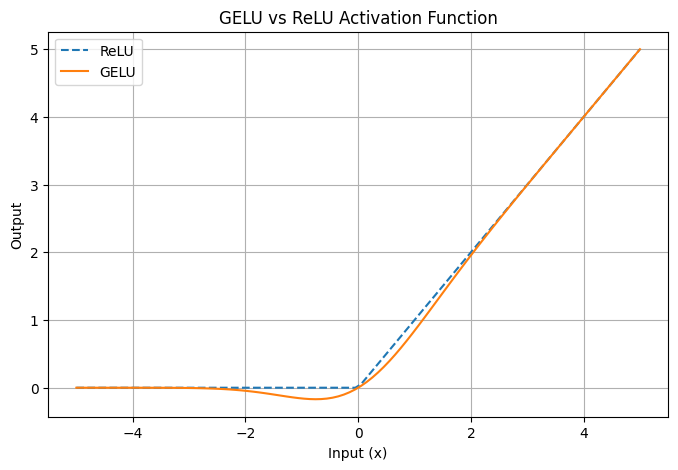


Example tensor: tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
GELU output for example tensor: tensor([-0.0455, -0.1543,  0.0000,  0.3457,  1.9545])
ReLU output for example tensor: tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])


In [44]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Create a range of input values from -5 to 5
x = torch.linspace(-5, 5, 100)

# Apply GELU
gelu_output = nn.GELU()(x)

# Apply ReLU for comparison
relu_output = nn.ReLU()(x)

print("First 5 inputs (x):")
print(x[:5])
print("\nFirst 5 GELU outputs:")
print(gelu_output[:5])
print("\nFirst 5 ReLU outputs:")
print(relu_output[:5])

# Visualize GELU and ReLU
plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), relu_output.numpy(), label='ReLU', linestyle='--')
plt.plot(x.numpy(), gelu_output.numpy(), label='GELU')
plt.title('GELU vs ReLU Activation Function')
plt.xlabel('Input (x)')
plt.ylabel('Output')
plt.grid(True)
plt.legend()
plt.show()

# Example with specific tensor values (similar to previous ReLU example)
example_tensor = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
gelu_example_output = nn.GELU()(example_tensor)
relu_example_output = nn.ReLU()(example_tensor)

print("\nExample tensor:", example_tensor)
print("GELU output for example tensor:", gelu_example_output)
print("ReLU output for example tensor:", relu_example_output)


## `nn.Softmax`: For Probabilistic Outputs in Classification

While activation functions like ReLU and GELU introduce non-linearity *within* hidden layers to help the network learn complex patterns, **Softmax** serves a very different and specific purpose: it's typically used as the **output layer activation function for multi-class classification problems**.

### What is Softmax and How Does it Help?

Softmax takes a vector of arbitrary real numbers (often called 'logits' or 'scores' from the final linear layer of a network) and transforms them into a probability distribution. This means:

1.  **Probabilistic Interpretation:** Each element of the output vector will be a probability between 0 and 1.
2.  **Sums to One:** The sum of all elements in the output vector will be exactly 1.

This makes it ideal for classification, where you want to know the probability of an input belonging to each possible class.

The formula for Softmax for an input vector $z = [z_1, z_2, \dots, z_K]$ (where K is the number of classes) is:

$$ \text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} $$

Let's break down how this helps in the context of our previous discussion on linear layers and non-linearity:

*   **Connecting to Previous Layers:** Imagine the output of your final `nn.Linear` layer gives you raw scores for different classes. For example, if you're classifying images into 'cat', 'dog', or 'bird', the linear layer might output `[2.0, 1.0, 0.1]`. These numbers don't directly represent probabilities.

*   **Softmax's Role:** `nn.Softmax` then takes these raw scores and transforms them. The exponential function `e^z_i` ensures that all outputs are positive. Dividing by the sum of all exponentials ensures that the outputs sum to 1. So, `[2.0, 1.0, 0.1]` might become `[0.659, 0.242, 0.099]` after Softmax, clearly indicating a 65.9% probability of 'cat', 24.2% of 'dog', and 9.9% of 'bird'.

*   **Beyond Non-linearity:** Unlike ReLU or GELU which focus on introducing non-linearity to learn features, Softmax focuses on interpreting the model's final output as meaningful probabilities for classification tasks. It allows us to compare the model's predictions directly with one-hot encoded true labels using loss functions like Cross-Entropy Loss.

In [49]:
import torch
import torch.nn as nn

# Example raw scores (logits) from a final linear layer for a 3-class problem
# e.g., scores for 'cat', 'dog', 'bird'
logits = torch.tensor([2.0, 1.0, 0.1])
print("Raw scores (logits):\n", logits)

# Apply Softmax activation function
# dim=0 means apply Softmax across the only dimension present (the classes)
softmax_output = nn.Softmax(dim=0)(logits)

print("\nSoftmax output (probabilities):\n", softmax_output)
print("Sum of probabilities:", softmax_output.sum().item())

# Example with a batch of data (common in deep learning)
# Batch size of 2, 3 classes
batch_logits = torch.tensor([
    [2.0, 1.0, 0.1],  # Scores for first sample
    [0.5, 3.0, 1.5]   # Scores for second sample
])
print("\nBatch raw scores (logits):\n", batch_logits)

# Apply Softmax along dimension 1 (across the classes for each sample)
batch_softmax_output = nn.Softmax(dim=1)(batch_logits)

print("\nBatch Softmax output (probabilities):\n", batch_softmax_output)
print("Sum of probabilities for first sample:", batch_softmax_output[0].sum().item())
print("Sum of probabilities for second sample:", batch_softmax_output[1].sum().item())

# What happens if we apply ReLU here?
relu_on_logits = nn.ReLU()(logits)
print("\nReLU applied to raw scores (for comparison):\n", relu_on_logits)


Raw scores (logits):
 tensor([2.0000, 1.0000, 0.1000])

Softmax output (probabilities):
 tensor([0.6590, 0.2424, 0.0986])
Sum of probabilities: 1.0000001192092896

Batch raw scores (logits):
 tensor([[2.0000, 1.0000, 0.1000],
        [0.5000, 3.0000, 1.5000]])

Batch Softmax output (probabilities):
 tensor([[0.6590, 0.2424, 0.0986],
        [0.0629, 0.7662, 0.1710]])
Sum of probabilities for first sample: 1.0000001192092896
Sum of probabilities for second sample: 1.0

ReLU applied to raw scores (for comparison):
 tensor([2.0000, 1.0000, 0.1000])


In [52]:
import torch
import torch.nn as nn

# --- Example 1: Simple word embeddings ---

# Imagine a vocabulary of 10 unique words
vocabulary_size = 10

# We want each word to be represented by a 5-dimensional vector
embedding_dim = 5

# Create the embedding layer
# It initializes a lookup table of shape (vocabulary_size, embedding_dim)
embedding_layer = nn.Embedding(num_embeddings=vocabulary_size, embedding_dim=embedding_dim)

print(f"Embedding layer created: {embedding_layer}")
print(f"Initial weights (embedding vectors) shape: {embedding_layer.weight.shape}")
print(f"Initial weights (first 3):\n{embedding_layer.weight[:3]}")

# Input: a tensor of word IDs (integers). These MUST be < vocabulary_size.
# Let's represent a short 'sentence' with word IDs:
# word_id_0, word_id_3, word_id_1, word_id_0
word_ids = torch.tensor([0, 3, 1, 0], dtype=torch.long)
print(f"\nInput word IDs: {word_ids}")

# Pass the word IDs through the embedding layer
# The output will be a tensor where each word ID is replaced by its 5-dim embedding vector
embedded_sentence = embedding_layer(word_ids)

print(f"\nOutput embedded sentence shape: {embedded_sentence.shape}")
print(f"Embedded sentence (each row is a word's embedding):\n{embedded_sentence}")

# --- Example 2: Batch of sentences ---

# Imagine a batch of 2 sentences, each with 4 words
# (Padding might be needed for real-world variable-length sentences, but omitted for simplicity)

batch_word_ids = torch.tensor([
    [0, 3, 1, 0],  # Sentence 1: word_id_0, word_id_3, word_id_1, word_id_0
    [2, 5, 8, 7]   # Sentence 2: word_id_2, word_id_5, word_id_8, word_id_7
], dtype=torch.long)

print(f"\nInput batch of word IDs (shape: {batch_word_ids.shape}):\n{batch_word_ids}")

batch_embedded_sentences = embedding_layer(batch_word_ids)

print(f"\nOutput batch of embedded sentences (shape: {batch_embedded_sentences.shape}):\n{batch_embedded_sentences}")
print("  (Batch size x Sentence Length x Embedding Dimension)")

# --- Analogy: Looking up a student's profile ---

# Imagine 5 students, each with a 'profile' (embedding vector) of 3 features
num_students = 5
profile_features = 3
student_embeddings = nn.Embedding(num_students, profile_features)

# Student IDs we want to look up
student_ids = torch.tensor([0, 2, 0, 4], dtype=torch.long)

student_profiles = student_embeddings(student_ids)

print(f"\nStudent profiles for IDs {student_ids}:\n{student_profiles}")
print(f"Shape: {student_profiles.shape}")


Embedding layer created: Embedding(10, 5)
Initial weights (embedding vectors) shape: torch.Size([10, 5])
Initial weights (first 3):
tensor([[ 0.7093,  0.0101,  0.8924,  0.2809, -1.4006],
        [-0.7445, -1.0799, -2.5342,  0.6130, -0.4142],
        [-0.5965, -0.2845, -0.3036, -0.0793,  1.5601]],
       grad_fn=<SliceBackward0>)

Input word IDs: tensor([0, 3, 1, 0])

Output embedded sentence shape: torch.Size([4, 5])
Embedded sentence (each row is a word's embedding):
tensor([[ 0.7093,  0.0101,  0.8924,  0.2809, -1.4006],
        [-0.9508,  0.7085, -0.7107, -1.0184, -0.3115],
        [-0.7445, -1.0799, -2.5342,  0.6130, -0.4142],
        [ 0.7093,  0.0101,  0.8924,  0.2809, -1.4006]],
       grad_fn=<EmbeddingBackward0>)

Input batch of word IDs (shape: torch.Size([2, 4])):
tensor([[0, 3, 1, 0],
        [2, 5, 8, 7]])

Output batch of embedded sentences (shape: torch.Size([2, 4, 5])):
tensor([[[ 0.7093,  0.0101,  0.8924,  0.2809, -1.4006],
         [-0.9508,  0.7085, -0.7107, -1.0184, 

## `nn.LayerNorm`: Stabilizing Neural Network Training

As neural networks get deeper, a common problem arises: the distribution of activations (the outputs of layers) can change dramatically during training. This phenomenon, known as **internal covariate shift**, can make training unstable and slow down convergence. To combat this, **normalization layers** are used.

### What is Normalization?

Normalization aims to transform the inputs to a layer so that they have a more stable distribution (e.g., zero mean and unit variance). This generally leads to more stable training, faster convergence, and sometimes better generalization.

Two popular types are Batch Normalization and Layer Normalization.

### `nn.LayerNorm` vs. `nn.BatchNorm`:

*   **Batch Normalization (`nn.BatchNorm`)**: Normalizes *across* the batch dimension. For each feature, it calculates the mean and variance over all samples in the current mini-batch. This works well for image data (CNNs) where features are consistent across the batch.

*   **Layer Normalization (`nn.LayerNorm`)**: Normalizes *across* the feature dimension for each individual sample. For each sample in the batch, it calculates the mean and variance over all the features within that sample. LayerNorm is particularly effective for sequential data (like NLP with RNNs/Transformers) where batch statistics might be less stable or meaningful due to variable sequence lengths, and for very small mini-batches where batch normalization statistics can be noisy.

### How `nn.LayerNorm` Works:

For a given input $x$, Layer Normalization applies the following transformation:

$$ y = \frac{x - \text{E}[x]}{\sqrt{\text{Var}[x] + \epsilon}} \cdot \gamma + \beta $$

Where:
*   $\text{E}[x]$ and $\text{Var}[x]$ are the mean and variance calculated over the features of a single input sample.
*   $\epsilon$ is a small constant to prevent division by zero.
*   $\gamma$ (gamma) and $\beta$ (beta) are learnable affine transformation parameters. They allow the network to learn to scale and shift the normalized output if it's beneficial for the model.

`nn.LayerNorm` takes the `normalized_shape` as its primary argument, which specifies the shape of the features (or a subset of features) that should be normalized. For a 2D input `(batch_size, features)`, `nn.LayerNorm(features)` normalizes each sample across its feature dimension. For a 3D input `(batch_size, sequence_length, embedding_dim)`, `nn.LayerNorm(embedding_dim)` normalizes each token (at `embedding_dim`) across its feature dimension.

### When to Use `nn.LayerNorm`:

Layer Normalization is widely used in:

*   **Transformer models:** It's a key component in the encoder and decoder blocks.
*   **Recurrent Neural Networks (RNNs):** Helps stabilize training, especially in deeper RNNs.
*   **Situations with varying input lengths:** Since it normalizes per sample, it's less sensitive to batch statistics, which can be inconsistent with padding or variable sequence lengths.
*   **Small batch sizes:** When batch statistics are unreliable, LayerNorm performs more robustly.

It helps to ensure that the inputs to subsequent layers have a consistent scale and distribution, preventing exploding or vanishing gradients and allowing for deeper, more stable models.

In [53]:
import torch
import torch.nn as nn

# --- Example 1: Simple 2D input (batch_size, features) ---

# Let's say we have a batch of 3 samples, each with 5 features
# The values are arbitrary, but note the different scales
dummy_input_2d = torch.tensor([
    [1.0, 2.0, 3.0, 4.0, 5.0],        # Sample 1
    [100.0, 200.0, 300.0, 400.0, 500.0],  # Sample 2 (much larger values)
    [-0.5, 0.0, 0.5, 1.0, 1.5]         # Sample 3 (smaller values)
], dtype=torch.float32)

print(f"Original 2D input:\n{dummy_input_2d}")

# Initialize LayerNorm to normalize across the last dimension (features)
# The 'normalized_shape' should match the dimension(s) you want to normalize over.
# Here, it's the 5 features of each sample.
layer_norm_2d = nn.LayerNorm(dummy_input_2d.shape[-1]) # or nn.LayerNorm(5)

# Apply Layer Normalization
normalized_output_2d = layer_norm_2d(dummy_input_2d)

print(f"\nOutput after LayerNorm (2D input):\n{normalized_output_2d}")
print(f"Output shape: {normalized_output_2d.shape}")

# Verify mean and variance for one sample (should be close to 0 and 1, respectively)
print(f"\nMean of first sample after LayerNorm: {normalized_output_2d[0].mean():.4f}")
print(f"Variance of first sample after LayerNorm: {normalized_output_2d[0].var(unbiased=False):.4f}")

# --- Example 2: 3D input (batch_size, sequence_length, embedding_dim) ---

# Common in NLP, where you have a batch of sequences, and each token in the sequence
# is represented by an embedding vector.

# Batch size = 2
# Sequence length = 4
# Embedding dimension = 3
dummy_input_3d = torch.randn(2, 4, 3)
print(f"\nOriginal 3D input (batch_size, seq_len, embedding_dim):\n{dummy_input_3d}")
print(f"Input shape: {dummy_input_3d.shape}")

# We want to normalize each embedding vector (across its 3 dimensions).
# So, normalized_shape should be 'embedding_dim'.
layer_norm_3d = nn.LayerNorm(dummy_input_3d.shape[-1]) # or nn.LayerNorm(3)

# Apply Layer Normalization
normalized_output_3d = layer_norm_3d(dummy_input_3d)

print(f"\nOutput after LayerNorm (3D input):\n{normalized_output_3d}")
print(f"Output shape: {normalized_output_3d.shape}")

# Verify mean and variance for a single embedding vector (e.g., first token of first sample)
print(f"\nMean of first embedding of first sample: {normalized_output_3d[0, 0].mean():.4f}")
print(f"Variance of first embedding of first sample: {normalized_output_3d[0, 0].var(unbiased=False):.4f}")


Original 2D input:
tensor([[  1.0000,   2.0000,   3.0000,   4.0000,   5.0000],
        [100.0000, 200.0000, 300.0000, 400.0000, 500.0000],
        [ -0.5000,   0.0000,   0.5000,   1.0000,   1.5000]])

Output after LayerNorm (2D input):
tensor([[-1.4142, -0.7071,  0.0000,  0.7071,  1.4142],
        [-1.4142, -0.7071,  0.0000,  0.7071,  1.4142],
        [-1.4142, -0.7071,  0.0000,  0.7071,  1.4142]],
       grad_fn=<NativeLayerNormBackward0>)
Output shape: torch.Size([3, 5])

Mean of first sample after LayerNorm: 0.0000
Variance of first sample after LayerNorm: 1.0000

Original 3D input (batch_size, seq_len, embedding_dim):
tensor([[[ 0.0482, -0.2673,  1.9553],
         [-0.5069,  0.2337,  0.4443],
         [-0.5609,  1.1635, -0.0063],
         [ 2.6407,  1.0287,  0.0349]],

        [[-0.0145, -1.1215,  1.7553],
         [-0.3084,  0.1528, -0.7115],
         [-0.9195, -0.0076, -0.7937],
         [ 0.1506, -1.5928,  0.3043]]])
Input shape: torch.Size([2, 4, 3])

Output after LayerNorm (3D

Here's what's actually happening and when you'd reach for it.
The problem it solves. As values flow through a deep network, they can drift wildly — one neuron outputs 47, another outputs -18. When these feed into the next layer's weights, the large values dominate, gradients explode or vanish, and the network becomes very hard to train. This gets worse the deeper your network is.
##What LayerNorm does, step by step.
For a single sample passing through, it looks at all the values in that layer at once and computes their mean and standard deviation. It then subtracts the mean and divides by the std, so all values are now centred around 0 with a std of 1. Then it applies two learned parameters — gamma (γ) to rescale, and beta (β) to shift.




In [58]:
from IPython.display import HTML

html_content = """
<style>
  .bar-wrap { display:flex; align-items:flex-end; gap:6px; height:120px; margin:0.5rem 0; }
  .bar { flex:1; border-radius:4px 4px 0 0; transition:height 0.4s, background 0.4s; min-width:28px; }
  .bar-label { font-size:11px; color:var(--color-text-secondary); text-align:center; margin-top:4px; }
  .bar-val { font-size:11px; font-weight:500; text-align:center; color:var(--color-text-primary); margin-top:2px; }
  .section-label { font-size:12px; font-weight:500; color:var(--color-text-secondary); margin:1rem 0 0.25rem; text-transform:uppercase; letter-spacing:0.04em; }
  .formula-box { background:var(--color-background-secondary); border:0.5px solid var(--color-border-tertiary); border-radius:var(--border-radius-md); padding:10px 14px; font-size:13px; color:var(--color-text-primary); margin:0.75rem 0; font-family:var(--font-mono); }
  .stat-row { display:flex; gap:12px; margin:0.5rem 0; }
  .stat { background:var(--color-background-secondary); border-radius:var(--border-radius-md); padding:8px 14px; flex:1; }
  .stat-name { font-size:11px; color:var(--color-text-secondary); }
  .stat-val { font-size:18px; font-weight:500; color:var(--color-text-primary); }
  .slider-row { display:flex; align-items:center; gap:10px; margin:0.4rem 0; }
  .slider-row label { font-size:13px; color:var(--color-text-secondary); min-width:80px; }
  .slider-row input[type=range] { flex:1; }
  .slider-row span { font-size:13px; font-weight:500; min-width:36px; text-align:right; color:var(--color-text-primary); }
  .pill { display:inline-block; font-size:11px; padding:2px 10px; border-radius:99px; font-weight:500; }
  .pill-warn { background:var(--color-background-warning); color:var(--color-text-warning); }
  .pill-ok { background:var(--color-background-success); color:var(--color-text-success); }
  .divider { border:none; border-top:0.5px solid var(--color-border-tertiary); margin:1.25rem 0; }
</style>

<div style="padding:1rem 0">

  <div class="section-label">Raw activations coming into the layer <span class="pill pill-warn">unstable</span></div>
  <div id="bars-before" class="bar-wrap"></div>
  <div id="labels-before" style="display:flex;gap:6px;margin-bottom:0.25rem;"></div>

  <div class="stat-row">
    <div class="stat"><div class="stat-name">Mean</div><div class="stat-val" id="mean-before">—</div></div>
    <div class="stat"><div class="stat-name">Std dev</div><div class="stat-val" id="std-before">—</div></div>
    <div class="stat"><div class="stat-name">Range</div><div class="stat-val" id="range-before">—</div></div>
  </div>

  <div class="formula-box">
    x̂ᵢ = (xᵢ − μ) / (σ + ε)    ← normalize to mean=0, std=1
    <br>yᵢ = γ · x̂ᵢ + β          ← rescale with learned γ, β
  </div>

  <div class="section-label">After LayerNorm <span class="pill pill-ok">stable</span></div>
  <div id="bars-after" class="bar-wrap"></div>
  <div id="labels-after" style="display:flex;gap:6px;margin-bottom:0.25rem;"></div>

  <div class="stat-row">
    <div class="stat"><div class="stat-name">Mean</div><div class="stat-val" id="mean-after">—</div></div>
    <div class="stat"><div class="stat-name">Std dev</div><div class="stat-val" id="std-after">—</div></div>
    <div class="stat"><div class="stat-name">Range</div><div class="stat-val" id="range-after">—</div></div>
  </div>

  <hr class="divider">
  <div class="section-label">Tweak the learned parameters</div>

  <div class="slider-row">
    <label>γ (scale)</label>
    <input type="range" id="gamma" min="0.1" max="3" step="0.1" value="1">
    <span id="gamma-out">1.0</span>
  </div>
  <div class="slider-row">
    <label>β (shift)</label>
    <input type="range" id="beta" min="-2" max="2" step="0.1" value="0">
    <span id="beta-out">0.0</span>
  </div>

  <hr class="divider">
  <div class="section-label">Randomise inputs</div>
  <button onclick="randomize()" style="margin-bottom:0.5rem;">Shuffle activations ↗</button>
  <button onclick="sendPrompt('Where exactly is LayerNorm placed inside a Transformer block?')">Where does it go in a Transformer? ↗</button>
</div>

<script>
const N = 7;
let raw = [12, -3, 47, 0.5, -18, 33, 8];

function mean(a) { return a.reduce((s,v)=>s+v,0)/a.length; }
function std(a) { const m=mean(a); return Math.sqrt(a.reduce((s,v)=>s+(v-m)**2,0)/a.length); }

function render() {
  const gamma = parseFloat(document.getElementById('gamma').value);
  const beta  = parseFloat(document.getElementById('beta').value);
  document.getElementById('gamma-out').textContent = gamma.toFixed(1);
  document.getElementById('beta-out').textContent  = beta.toFixed(1);

  const m = mean(raw), s = std(raw);
  const normed = raw.map(x => (x - m) / (s + 1e-5));
  const out    = normed.map(x => gamma * x + beta);

  const allRaw = [...raw];
  const maxAbs = Math.max(...allRaw.map(Math.abs), 1);

  function makeBars(containerId, labelId, vals, maxA, color) {
    const bw = document.getElementById(containerId);
    const lb = document.getElementById(labelId);
    bw.innerHTML = ''; lb.innerHTML = '';
    vals.forEach((v, i) => {
      const pct = Math.min(Math.abs(v) / maxA, 1);
      const h = Math.max(pct * 110, 4);
      const bar = document.createElement('div');
      bar.className = 'bar';
      bar.style.height = h + 'px';
      bar.style.background = color;
      bar.style.opacity = v < 0 ? '0.45' : '1';
      bar.style.flex = '1';
      bar.title = v.toFixed(2);
      bw.appendChild(bar);

      const lbl = document.createElement('div');
      lbl.style.flex = '1';
      lbl.innerHTML = `<div class="bar-label">x${i+1}</div><div class="bar-val">${v.toFixed(1)}</div>`;
      lb.appendChild(lbl);
    });
  }

  makeBars('bars-before', 'labels-before', raw, maxAbs, '#D85A30');

  const outMax = Math.max(...out.map(Math.abs), 1);
  makeBars('bars-after', 'labels-after', out, Math.max(outMax, 2), '#1D9E75');

  document.getElementById('mean-before').textContent = m.toFixed(2);
  document.getElementById('std-before').textContent  = s.toFixed(2);
  document.getElementById('range-before').textContent = (Math.max(...raw) - Math.min(...raw)).toFixed(1);

  const om = mean(out), os = std(out);
  document.getElementById('mean-after').textContent = om.toFixed(2);
  document.getElementById('std-after').textContent  = os.toFixed(2);
  document.getElementById('range-after').textContent = (Math.max(...out) - Math.min(...out)).toFixed(2);
}

function randomize() {
  raw = Array.from({length: N}, () => (Math.random() - 0.4) * 60);
  render();
}

document.getElementById('gamma').addEventListener('input', render);
document.getElementById('beta').addEventListener('input', render);
render();
</script>
"""

HTML(html_content)





Try dragging those sliders in the widget above to see this effect. The key insight is that the network gets to learn what scale and shift work best, rather than being stuck with the raw chaotic values.



##How it differs from BatchNorm
BatchNorm normalises across the batch dimension (it looks at the same feature across many samples). LayerNorm normalises across the feature dimension (it looks at all features within one single sample). This makes LayerNorm much better when:

Your batch size is small or variable
You're processing sequences of different lengths (like text)
You're using RNNs or Transformers

##When you'd actually use it in code.
The classic scenario is a Transformer. Inside every transformer block, LayerNorm is placed right before (or after, depending on the implementation) the attention and feed-forward sub-layers:
pythonimport torch.nn as nn



```
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads)
        self.ff   = nn.Sequential(nn.Linear(d_model, d_model*4), nn.ReLU(), nn.Linear(d_model*4, d_model))
        self.norm1 = nn.LayerNorm(d_model)  # <-- after attention
        self.norm2 = nn.LayerNorm(d_model)  # <-- after feed-forward

    def forward(self, x):
        x = self.norm1(x + self.attn(x, x, x)[0])
        x = self.norm2(x + self.ff(x))

        return x
```
You'd also reach for nn.LayerNorm in deep MLPs where you're seeing training instability, or in any RNN where batch sizes vary. The short rule: if you're working with sequences or small batches, LayerNorm. If you're doing image classification with large fixed batches, BatchNorm is usually better.

# PyTorch Deep Learning — Core Concepts

## 1. `nn.Module` — The Base Class for Every Model

Every model you build in PyTorch, from the simplest linear regression to the most complex Transformer, must inherit from `torch.nn.Module`. This class is the backbone for all neural network modules and gives you essential functionality:

*   **Parameter Management:** It automatically tracks all learnable parameters (weights and biases) defined within your model. This is crucial for optimizers to know what to update.
*   **Mode Switching:** It provides `.train()` and `.eval()` methods to switch the model between training and inference modes, which affects behaviors like `nn.Dropout` and `nn.BatchNorm`.
*   **Moving to Device:** It allows you to easily move your entire model (all its parameters) to a different device (e.g., CPU to GPU) using `.to(device)`.
*   **Submodule Management:** If your model contains other `nn.Module` instances (e.g., an `nn.Linear` layer), `nn.Module` correctly registers them, allowing you to access their parameters and apply operations across the whole model.

When creating your own custom model class, you *must* define two things:

1.  **`__init__(self, ...)`:** In the constructor, you declare all the layers (like `nn.Linear`, `nn.Embedding`, etc.) and any other parameters your model will use. Remember to always call `super().__init__()` as the very first line inside your `__init__` method – this initializes PyTorch's internal machinery.
2.  **`forward(self, x)`:** This method defines the computational graph. It describes how data flows through your declared layers and operations to produce an output. When you call your model instance (e.g., `model(input_data)`), PyTorch automatically executes this `forward` method.

Let's see a simple example of a `TinyModel` demonstrating this structure.

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim

print('PyTorch version:', torch.__version__)

class TinyModel(nn.Module):              # <-- inherit from nn.Module

    def __init__(self):
        super().__init__()               # <-- ALWAYS call this first
        self.layer = nn.Linear(3, 1)     # declare layers as attributes

    def forward(self, x):               # PyTorch calls this when you do model(x)
        return self.layer(x)

model = TinyModel()
print(model)                            # prints the architecture

print('\nAll parameters:')
for name, param in model.named_parameters():
    print(f'  {name:20s}  shape={list(param.shape)}  values={param.data}')

PyTorch version: 2.10.0+cpu
TinyModel(
  (layer): Linear(in_features=3, out_features=1, bias=True)
)

All parameters:
  layer.weight          shape=[1, 3]  values=tensor([[0.4091, 0.0884, 0.1757]])
  layer.bias            shape=[1]  values=tensor([0.1328])


## 2. Rebuilding a Linear Regression Model with `nn.Linear`

We previously built a linear regression model from scratch using `X @ W_model + b_model`. Now, let's see how `nn.Linear` encapsulates this functionality within an `nn.Module`.

`nn.Linear(in_features, out_features)` creates a single fully-connected layer. Internally, it manages:

*   A **weight matrix (W)**: Its shape is `(out_features, in_features)`.
*   A **bias vector (b)**: Its shape is `(out_features,)`.

When you pass an input `x` through an `nn.Linear` layer, it computes the output `y` using the formula: **y = x @ W.T + b** (where `W.T` is the transpose of the weight matrix, matching the input `x`'s dimensions for matrix multiplication). This effectively performs a linear transformation on the input data.

Let's define our `LinearRegression` model using `nn.Linear`.

In [60]:
class LinearRegression(nn.Module):
    """
    Maps a feature input to a single number output.
    Just one linear layer — no activation (regression, not classification).
    """
    def __init__(self, input_features: int, output_features: int):
        super().__init__()
        self.linear_layer = nn.Linear(input_features, output_features)

    def forward(self, x):
        return self.linear_layer(x)


lr_model = LinearRegression(input_features=5, output_features=1)
print(lr_model)

# Feed a batch of 3 samples, each with 5 features
dummy_input = torch.randn(3, 5)          # shape: [batch=3, features=5]
output = lr_model(dummy_input)           # calls forward() under the hood
print(f'\nInput shape:  {dummy_input.shape}')
print(f'Output shape: {output.shape}')

LinearRegression(
  (linear_layer): Linear(in_features=5, out_features=1, bias=True)
)

Input shape:  torch.Size([3, 5])
Output shape: torch.Size([3, 1])


## 3. `torch.optim` — Updating the Weights Efficiently

While we manually updated parameters in our first training loop, `torch.optim` provides a cleaner and more efficient way to handle this. An **optimizer** object is responsible for implementing specific optimization algorithms (like Stochastic Gradient Descent, Adam, etc.) to adjust your model's parameters based on the computed gradients.

After you've performed a forward pass and computed the `loss`:

1.  **`optimizer.zero_grad()`**: This crucial step clears any old gradients from previous iterations. Gradients accumulate by default in PyTorch, so resetting them ensures you're only using the gradients from the current batch.
2.  **`loss.backward()`**: This is where PyTorch's Autograd engine kicks in. It traverses the computational graph backward from the `loss` tensor, computing the gradients of the loss with respect to all parameters that have `requires_grad=True`.
3.  **`optimizer.step()`**: The optimizer then uses these newly computed gradients (stored in the `.grad` attribute of each parameter) to update the parameters according to its specific algorithm (e.g., standard Gradient Descent, Adam, etc.) and the learning rate you provided.

Let's integrate an optimizer into a simple training loop.

In [61]:
model = LinearRegression(5, 1)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Fake dataset: 100 samples, 5 features
X = torch.randn(100, 5)
y = torch.randn(100, 1)

print('Training for 5 steps:')
for step in range(5):
    preds = model(X)                  # 1. forward pass
    loss  = loss_fn(preds, y)         # 2. compute loss

    optimizer.zero_grad()             # 3. clear old gradients
    loss.backward()                   # 4. compute new gradients
    optimizer.step()                  # 5. update weights

    print(f'  step {step+1}  loss={loss.item():.4f}')

Training for 5 steps:
  step 1  loss=1.5698
  step 2  loss=1.5666
  step 3  loss=1.5635
  step 4  loss=1.5604
  step 5  loss=1.5572


## 4. `nn.Dropout` — Managing Overfitting with Train vs. Eval Mode

`nn.Dropout` is a regularization technique that helps prevent neural networks from overfitting, especially in deeper models. During training, it randomly sets a fraction (`p`) of the input features (or neuron activations) to zero. This forces the network to learn more robust and redundant representations, as it cannot rely on any single neuron always being active.

**The crucial point about Dropout is its behavior in different modes:**

*   **Training Mode (`model.train()`):** When the model is in training mode, `nn.Dropout` actively zeros out neurons. This means your network behaves differently in each training step, promoting generalization.
*   **Evaluation Mode (`model.eval()`):** During inference or evaluation (when you're making predictions with a trained model), you *do not* want neurons to be randomly dropped. In this mode, `nn.Dropout` simply passes all inputs through unchanged, effectively scaling the remaining weights to compensate for the dropped neurons during training.

It's vital to switch your model between `.train()` and `.eval()` modes as appropriate. This applies not just to `nn.Dropout`, but also to other layers like `nn.BatchNorm` which behave differently in each mode. PyTorch automatically propagates this mode switch to all sub-modules within your `nn.Module`.

In [62]:
class ModelWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear  = nn.Linear(8, 8)
        self.dropout = nn.Dropout(p=0.5)  # 50% of neurons zeroed during training

    def forward(self, x):
        x = self.linear(x)
        x = self.dropout(x)
        return x


m = ModelWithDropout()
x = torch.ones(1, 8)

# --- TRAIN MODE ---
m.train()
out_train = m(x)
print('TRAIN MODE — some values zeroed out:')
print(out_train.detach())
print(f'  Non-zero elements: {(out_train != 0).sum().item()} / 8')

print()

# --- EVAL MODE ---
m.eval()
with torch.no_grad():                 # also disable gradient tracking at inference
    out_eval = m(x)
print('EVAL MODE — all values pass through:')
print(out_eval.detach())
print(f'  Non-zero elements: {(out_eval != 0).sum().item()} / 8')

TRAIN MODE — some values zeroed out:
tensor([[-0.0000, 0.0000, 3.5713, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
  Non-zero elements: 1 / 8

EVAL MODE — all values pass through:
tensor([[-0.5076,  0.6691,  1.7857,  0.2564,  0.2512,  0.5888,  0.3003,  0.6596]])
  Non-zero elements: 8 / 8


## 5. Transformer Feed-Forward Network (FFN)

In Transformer architectures (the basis for models like BERT, GPT, LLaMA), each Transformer block contains a Feed-Forward Network (FFN). This FFN's primary role is to process each token's representation *independently* through a two-layer Multi-Layer Perceptron (MLP).

The typical structure of an FFN is:

```
x  →  Linear(embed_dim → ffn_dim)  →  Activation  →  Linear(ffn_dim → embed_dim)  →  out
```

Key characteristics:

*   **Expansion and Projection:** The first linear layer expands the token's representation from `embed_dim` to a higher dimension (`ffn_dim`). The second linear layer then projects it back down to the original `embed_dim`.
*   **`ffn_dim`:** This dimension is typically a multiple (often 4x) of the `embed_dim`. This expansion allows the network to learn more complex features before projecting them back. This 4x factor has been a consistent design choice since the original Transformer paper.
*   **Activation Function:** Between the two linear layers, a non-linear activation function is applied. While ReLU was historically common, **GELU (`nn.GELU`)** is often preferred in modern Transformers. GELU is a smoother approximation of ReLU, which can lead to better gradient flow and performance in very deep networks.

Let's define and inspect a `FeedForwardNetwork`.

In [63]:
class FeedForwardNetwork(nn.Module):
    """
    The FFN sub-layer inside a Transformer block.

    Expands the representation to a higher dimension (ffn_dim),
    applies a non-linearity, then projects back to embed_dim.
    """
    def __init__(self, embed_dim: int, ffn_dim: int):
        super().__init__()
        self.layer1      = nn.Linear(embed_dim, ffn_dim)   # expand
        self.activation  = nn.GELU()                        # smooth non-linearity
        self.layer2      = nn.Linear(ffn_dim, embed_dim)   # project back

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x


embed_dim = 512
ffn_dim   = embed_dim * 4   # standard 4x expansion

ffn = FeedForwardNetwork(embed_dim, ffn_dim)
print(ffn)

# Input: batch of 2 sequences, each 10 tokens long, each token is a 512-dim vector
x = torch.randn(2, 10, embed_dim)   # [batch, seq_len, embed_dim]
out = ffn(x)
print(f'\nInput  shape: {list(x.shape)}')
print(f'Output shape: {list(out.shape)}')   # same shape — embed_dim preserved

total = sum(p.numel() for p in ffn.parameters())
print(f'\nTotal parameters in this FFN: {total:,}')

FeedForwardNetwork(
  (layer1): Linear(in_features=512, out_features=2048, bias=True)
  (activation): GELU(approximate='none')
  (layer2): Linear(in_features=2048, out_features=512, bias=True)
)

Input  shape: [2, 10, 512]
Output shape: [2, 10, 512]

Total parameters in this FFN: 2,099,712


## 6. Weight Matrices — What `nn.Linear` Actually Holds

Understanding `nn.Linear` at a deeper level is key to grasping how parameters contribute to model size. When you define `nn.Linear(in_features, out_features)`, PyTorch internally creates a weight matrix **W** of shape `(out_features, in_features)` and a bias vector **b** of shape `(out_features,)`.

During a forward pass, the operation performed is `output = input @ W.T + b`. Let's visualize this with two very different scales:

*   **Toy Model:** A simple `nn.Linear(1, 1)` has a tiny weight matrix and bias, easy to inspect.
*   **LLM Scale:** In large language models, a single `nn.Linear` layer can have millions or even billions of parameters. For example, a layer expanding the embedding dimension of 4096 to an FFN dimension of 14336 (common in LLaMA-style architectures) results in a huge weight matrix.

This comparison helps illustrate how model complexity and parameter count skyrocket in large deep learning models.

In [64]:
# --- TOY MODEL ---
toy_layer = nn.Linear(1, 1, bias=False)
W_toy = toy_layer.weight

x_toy = torch.tensor([[3.0]])    # shape [1, 1]
out_toy = x_toy @ W_toy.T        # manually do what nn.Linear does

print('=== TOY MODEL ===')
print(f'W shape:   {list(W_toy.shape)}')
print(f'W value:   {W_toy.item():.4f}')
print(f'x @ W.T =  {x_toy.item():.2f} × {W_toy.item():.4f} = {out_toy.item():.4f}')
print(f'Params:    {W_toy.numel()}')

print()

# --- LLM SCALE: one weight matrix from LLaMA-style FFN ---
# embed_dim=4096, ffn_dim=14336  (these are LLaMA-2 7B numbers)
llm_layer = nn.Linear(4096, 14336, bias=False)
W_llm = llm_layer.weight

print('=== LLM SCALE (one single weight matrix) ===')
print(f'W shape:   {list(W_llm.shape)}')
print(f'Params:    {W_llm.numel():,}   ({W_llm.numel()/1e6:.1f}M)')

x_llm = torch.randn(1, 4096)    # one token, embed_dim=4096
out_llm = x_llm @ W_llm.T       # same operation, much bigger
print(f'x shape:   {list(x_llm.shape)}')
print(f'out shape: {list(out_llm.shape)}')

=== TOY MODEL ===
W shape:   [1, 1]
W value:   0.3240
x @ W.T =  3.00 × 0.3240 = 0.9721
Params:    1

=== LLM SCALE (one single weight matrix) ===
W shape:   [14336, 4096]
Params:    58,720,256   (58.7M)
x shape:   [1, 4096]
out shape: [1, 14336]


## 7. Sense of Scale — Toy Model vs. LLM

To truly appreciate the scale of modern Large Language Models (LLMs), it's helpful to count parameters at various levels of complexity. "8 billion parameters" isn't just a big number; it represents an immense computational and memory footprint. This section will quantify parameter counts for:

1.  A tiny linear regression model.
2.  A small, multi-layer perceptron (MLP).
3.  A single Feed-Forward Network block at the scale seen in models like LLaMA.
4.  The cumulative parameters if you stack many such FFN blocks, giving a glimpse into the total parameter budget of an LLM.

This will provide context for what those large model sizes truly mean.

In [65]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())


# ── 1. Toy linear regression ──────────────────────────────────────
toy = nn.Linear(5, 1)
# W: (1,5) = 5 weights, b: (1,) = 1 bias → 6 params total


# ── 2. Small MLP (3 hidden layers) ───────────────────────────────
small_mlp = nn.Sequential(
    nn.Linear(784, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 10)
)


# ── 3. One Transformer FFN block at LLM scale ─────────────────────
# LLaMA-2 7B: embed_dim=4096, ffn_dim=14336, 32 layers
# There are TWO linear layers per FFN (gate_proj + up_proj) plus down_proj
# For simplicity, we model a standard 2-layer FFN
one_ffn = FeedForwardNetwork(embed_dim=4096, ffn_dim=14336)


# ── 4. Stack 32 FFN blocks (rough stand-in for a 7B model's FFN budget)
ffn_stack_params = count_params(one_ffn) * 32


print(f"{'Model':<40} {'Params':>15}")
print('-' * 57)
print(f"{'Toy linear regression (5→1)':<40} {count_params(toy):>15,}")
print(f"{'Small MLP (784→256→128→10)':<40} {count_params(small_mlp):>15,}")
print(f"{'One LLM-scale FFN (4096→14336→4096)':<40} {count_params(one_ffn):>15,}")
print(f"{'32× LLM FFN blocks (FFN budget only)':<40} {ffn_stack_params:>15,}")

print()
print('Context:')
print(f'  1 million  params = {1e6:.0e}  → small CNN, character-level RNN')
print(f'  100M params       = {1e8:.0e}  → BERT-base')
print(f'  7B  params        = {7e9:.0e}  → LLaMA-2 7B, Mistral 7B')
print(f'  70B params        = {7e10:.0e}  → LLaMA-2 70B')

# Memory: at float32, each param = 4 bytes. At bfloat16 = 2 bytes.
params_7b = 7_000_000_000
gb_fp32   = params_7b * 4 / 1e9
gb_bf16   = params_7b * 2 / 1e9
print(f'\n7B model memory:')
print(f'  float32:  {gb_fp32:.0f} GB')
print(f'  bfloat16: {gb_bf16:.0f} GB  (why 7B fits on one 24GB GPU when quantised)')

Model                                             Params
---------------------------------------------------------
Toy linear regression (5→1)                            6
Small MLP (784→256→128→10)                       235,146
One LLM-scale FFN (4096→14336→4096)          117,458,944
32× LLM FFN blocks (FFN budget only)       3,758,686,208

Context:
  1 million  params = 1e+06  → small CNN, character-level RNN
  100M params       = 1e+08  → BERT-base
  7B  params        = 7e+09  → LLaMA-2 7B, Mistral 7B
  70B params        = 7e+10  → LLaMA-2 70B

7B model memory:
  float32:  28 GB
  bfloat16: 14 GB  (why 7B fits on one 24GB GPU when quantised)


## 8. A Full Transformer Layer — Putting It All Together

With all the components we've discussed (`nn.Module`, `nn.Linear`, `nn.Dropout`, `nn.LayerNorm`, `nn.GELU` within an FFN), we can now assemble a complete **Transformer Layer**. This is the fundamental building block that gets stacked many times to form large Transformer models.

A typical Transformer layer combines two main sub-blocks:

1.  **Multi-Head Self-Attention:** This mechanism allows the model to weigh the importance of different parts of the input sequence when processing each element. PyTorch provides `nn.MultiheadAttention` for this.
2.  **Feed-Forward Network (FFN):** Our `FeedForwardNetwork` from the previous section.

Crucially, each of these sub-blocks is wrapped with two important architectural patterns:

*   **Residual Connections:** Often denoted as `x = x + sublayer(x)`, these connections add the input of a sub-block directly to its output. This helps combat the vanishing gradient problem in deep networks by providing a shortcut for gradients to flow. It's like having a bypass road when the main highway is congested.
*   **Layer Normalization (`nn.LayerNorm`):** As discussed, LayerNorm stabilizes the activations within the network, leading to more stable and faster training. In modern Transformers (like those used in large LLMs), LayerNorm is typically applied *before* the attention and FFN sub-layers (this is known as the "Pre-LN" variant).
*   **Dropout:** Applied after the residual connection for regularization.

Let's define a `TransformerLayer` and see how these pieces fit together.

In [66]:
class TransformerLayer(nn.Module):
    """
    One complete Transformer encoder layer.

    Structure (Pre-LN variant — used in modern LLMs):
        x → LayerNorm → Attention → residual add
          → LayerNorm → FFN       → residual add
    """
    def __init__(self, embed_dim: int, n_heads: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()

        # Sub-block 1: attention
        self.norm1   = nn.LayerNorm(embed_dim)
        self.attn    = nn.MultiheadAttention(embed_dim, n_heads,
                                             dropout=dropout, batch_first=True)
        self.drop1   = nn.Dropout(dropout)

        # Sub-block 2: feed-forward
        self.norm2   = nn.LayerNorm(embed_dim)
        self.ffn     = FeedForwardNetwork(embed_dim, ffn_dim)
        self.drop2   = nn.Dropout(dropout)

    def forward(self, x):
        # --- Attention sub-block ---
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)   # Q=K=V (self-attention)
        x = x + self.drop1(attn_out)                      # residual connection

        # --- FFN sub-block ---
        normed = self.norm2(x)
        ffn_out = self.ffn(normed)
        x = x + self.drop2(ffn_out)                       # residual connection

        return x


# Build one layer at a small (demo) scale
layer = TransformerLayer(embed_dim=128, n_heads=4, ffn_dim=512)
print(layer)
print(f'\nParameters in one layer: {count_params(layer):,}')

# Forward pass
batch, seq_len = 2, 16
x = torch.randn(batch, seq_len, 128)     # [batch, seq_len, embed_dim]

layer.eval()
with torch.no_grad():
    out = layer(x)
print(f'\nInput  shape: {list(x.shape)}')
print(f'Output shape: {list(out.shape)}')

TransformerLayer(
  (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (drop1): Dropout(p=0.1, inplace=False)
  (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (ffn): FeedForwardNetwork(
    (layer1): Linear(in_features=128, out_features=512, bias=True)
    (activation): GELU(approximate='none')
    (layer2): Linear(in_features=512, out_features=128, bias=True)
  )
  (drop2): Dropout(p=0.1, inplace=False)
)

Parameters in one layer: 198,272

Input  shape: [2, 16, 128]
Output shape: [2, 16, 128]


## 9. Counting Parameters — The Right Way (MiniLLM)

Now that we have the `TransformerLayer` as a building block, we can assemble a small, but architecturally complete, Large Language Model (LLM) and accurately count its parameters. This helps us understand how the reported billions of parameters are distributed across different parts of an LLM.

A typical Decoder-only Transformer (like GPT or LLaMA) consists of:

1.  **Token Embeddings (`nn.Embedding`):** Maps input token IDs to dense vector representations. Also includes positional embeddings to encode the order of tokens.
2.  **Stacked Transformer Layers:** Multiple `TransformerLayer` instances processed sequentially.
3.  **Final LayerNorm:** A normalization layer before the final prediction head.
4.  **Output Head (`nn.Linear`):** A linear layer that projects the final token representations back to the vocabulary size, producing logits for next-token prediction.

We'll build a `MiniLLM` at a "toy" scale that can run on any laptop, then compare its parameter count to the estimated breakdown of a real 7B parameter model.

In [67]:
class MiniLLM(nn.Module):
    """
    A tiny but architecturally honest LLM:
    Embedding → N Transformer layers → Linear head
    """
    def __init__(self, vocab_size, embed_dim, n_heads, ffn_dim, n_layers, max_seq_len):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding   = nn.Embedding(max_seq_len, embed_dim)

        self.layers = nn.ModuleList([
            TransformerLayer(embed_dim, n_heads, ffn_dim)
            for _ in range(n_layers)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size, bias=False)  # predict next token

    def forward(self, token_ids):
        B, T = token_ids.shape
        pos  = torch.arange(T, device=token_ids.device)

        x = self.token_embedding(token_ids) + self.pos_embedding(pos)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.head(x)   # logits over vocab, shape: [B, T, vocab_size]


# ── TOY scale (runs on any laptop) ───────────────────────────────
toy_llm = MiniLLM(
    vocab_size  = 1000,
    embed_dim   = 64,
    n_heads     = 4,
    ffn_dim     = 256,
    n_layers    = 2,
    max_seq_len = 128
)

toy_params = count_params(toy_llm)
print(f'Toy LLM parameters: {toy_params:,}')

# ── What a real 7B model looks like (params estimated, not run) ───
print()
print('Real LLaMA-2 7B breakdown (estimated):')
E, F, L, V = 4096, 14336, 32, 32000
embed_params = V * E
# Each layer: attn (4 matrices of E×E) + FFN (2×E×F + F×E) + norms
layer_params = (4 * E * E) + (2 * E * F + F * E) + (2 * E)
head_params  = E * V
total_est    = embed_params + L * layer_params + head_params
print(f'  Token embedding:   {embed_params:>15,}')
print(f'  Per layer:         {layer_params:>15,}')
print(f'  × {L} layers:        {L * layer_params:>15,}')
print(f'  Output head:       {head_params:>15,}')
print(f'  ─────────────────────────────')
print(f'  Total (estimated): {total_est:>15,}  ({total_est/1e9:.2f}B)')

Toy LLM parameters: 236,288

Real LLaMA-2 7B breakdown (estimated):
  Token embedding:       131,072,000
  Per layer:             243,277,824
  × 32 layers:          7,784,890,368
  Output head:           131,072,000
  ─────────────────────────────
  Total (estimated):   8,047,034,368  (8.05B)


## 10. Quick-Reference Cheat Sheet & Training Loop Skeleton

To consolidate our learning, here's a quick-reference table summarizing the core PyTorch concepts we've covered, followed by a general skeleton for a PyTorch training loop.

| Concept | What it is | Key call |
|---|---|---|
| `nn.Module` | Base class for all models | `super().__init__()` in `__init__` |
| `nn.Linear(in, out)` | Fully-connected layer — holds **W** and **b** | `forward(x)` computes `x @ W.T + b` |
| `nn.Dropout(p)` | Zeros neurons during training | `model.train()` / `model.eval()` |
| `nn.LayerNorm` | Normalises values within one sample | Place before attention & FFN |
| `nn.GELU` | Smooth activation — preferred in Transformers | replaces ReLU inside FFN |
| `torch.optim.Adam` | Adaptive gradient descent | `optimizer.zero_grad()` → `.backward()` → `.step()` |
| `model.parameters()` | Iterates all learnable tensors | Pass to optimizer |
| `p.numel()` | Count elements in a tensor | Used to count total params |

---

### The Full Training Loop Skeleton

```python
model     = MyModel()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()

# --- training ---
model.train()
for X_batch, y_batch in train_loader:
    preds = model(X_batch)         # forward
    loss  = loss_fn(preds, y_batch)
    optimizer.zero_grad()           # clear gradients
    loss.backward()                 # compute gradients
    optimizer.step()                # update weights

# --- evaluation ---
model.eval()
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        preds = model(X_batch)
        # Calculate metrics (accuracy, F1, etc.)
        ...
```